- importando as bibliotecas

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("assets", exist_ok=True)
import sqlite3
sns.set(style="whitegrid")

### Resolving Database Corruption

It appears the `database.sqlite` file is corrupted. To fix this, we need to download a fresh copy of the dataset.

First, you'll need to install the `opendatasets` library to download data from Kaggle. Then, you can use the `od.download()` function. You will be prompted to enter your Kaggle username and API key (which you can get from your Kaggle account settings).

In [32]:
# Install opendatasets for downloading Kaggle datasets
!pip install opendatasets

In [33]:
import opendatasets as od

# Provide the Kaggle dataset URL
dataset_url = 'https://www.kaggle.com/datasets/hugomathien/soccer'

# Download the dataset (you will be prompted for your Kaggle username and API key)
od.download(dataset_url)

print("Dataset downloaded successfully. The 'database.sqlite' file should now be refreshed.")

Skipping, found downloaded files in "./soccer" (use force=True to force download)
Dataset downloaded successfully. The 'database.sqlite' file should now be refreshed.


After running the above cells and successfully downloading the dataset, the `database.sqlite` file should be replaced. You can now re-run the cells that were failing, starting from the cell that connects to the database (`conn = sqlite3.connect("database.sqlite")`).

In [34]:
conn = sqlite3.connect("soccer/database.sqlite")

In [35]:

dados = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)



In [36]:

matches = pd.read_sql("SELECT * FROM Match;", conn)

matches.shape
matches.head()


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


- Entendendo a estrutura da tabela Match

In [37]:
matches.columns

Index(['id', 'country_id', 'league_id', 'season', 'stage', 'date',
       'match_api_id', 'home_team_api_id', 'away_team_api_id',
       'home_team_goal',
       ...
       'SJA', 'VCH', 'VCD', 'VCA', 'GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA'],
      dtype='object', length=115)

In [38]:
# Subconjunto de colunas para análise das partidas
partidas_eda = matches[
    [
        "season",
        "date",
        "home_team_api_id",
        "away_team_api_id",
        "home_team_goal",
        "away_team_goal"
    ]
].copy()

partidas_eda


,season,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,2008/2009,2008-08-17 00:00:00,9987,9993,1,1
1,2008/2009,2008-08-16 00:00:00,10000,9994,0,0
2,2008/2009,2008-08-16 00:00:00,9984,8635,0,3
3,2008/2009,2008-08-17 00:00:00,9991,9998,5,0
4,2008/2009,2008-08-16 00:00:00,7947,9985,1,3
...,...,...,...,...,...,...
25974,2015/2016,2015-09-22 00:00:00,10190,10191,1,0
25975,2015/2016,2015-09-23 00:00:00,9824,10199,1,2
25976,2015/2016,2015-09-23 00:00:00,9956,10179,2,0
25977,2015/2016,2015-09-22 00:00:00,7896,10243,0,0


In [39]:
# conferindo valores unicos
partidas_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   season            25979 non-null  object
 1   date              25979 non-null  object
 2   home_team_api_id  25979 non-null  int64 
 3   away_team_api_id  25979 non-null  int64 
 4   home_team_goal    25979 non-null  int64 
 5   away_team_goal    25979 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 1.2+ MB


In [40]:
#Converter a coluna de data
partidas_eda['date'] = pd.to_datetime(partidas_eda['date'])
partidas_eda["ano"] = partidas_eda["date"].dt.year

- Gols totais das partidas

In [41]:
partidas_eda['gols_totais'] = (
    partidas_eda['home_team_goal'] +
    partidas_eda['away_team_goal']
)


Resultado das partidas

In [42]:
def resultado_partida(linha):
    if linha['home_team_goal'] > linha['away_team_goal']:
        return 'Vitoria mandante'
    elif linha['home_team_goal'] < linha['away_team_goal']:
        return 'Vitoria visitante'
    else:
        return 'Empate'


partidas_eda["resultado"] = partidas_eda.apply(
    resultado_partida, axis=1
)


In [43]:
partidas_eda.head()

,season,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,ano,gols_totais,resultado
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante


Distribuindo gols por partidas

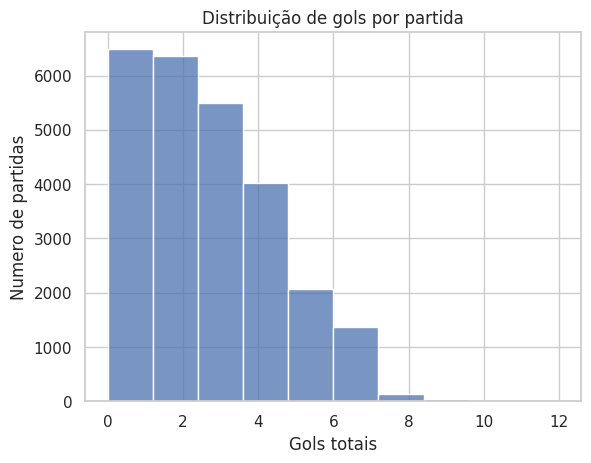

In [44]:
sns.histplot(partidas_eda['gols_totais'], bins=10)
plt.title('Distribuição de gols por partida')
plt.xlabel('Gols totais')
plt.ylabel('Numero de partidas')
plt.savefig("assets/distribuicao_gols_partida.png", dpi=150, bbox_inches="tight")
plt.show()

Distribuindo Resultados

In [45]:
partidas_eda['resultado'].value_counts(normalize= True)

,proportion
resultado,
Vitoria mandante,0.458717
Vitoria visitante,0.287386
Empate,0.253897


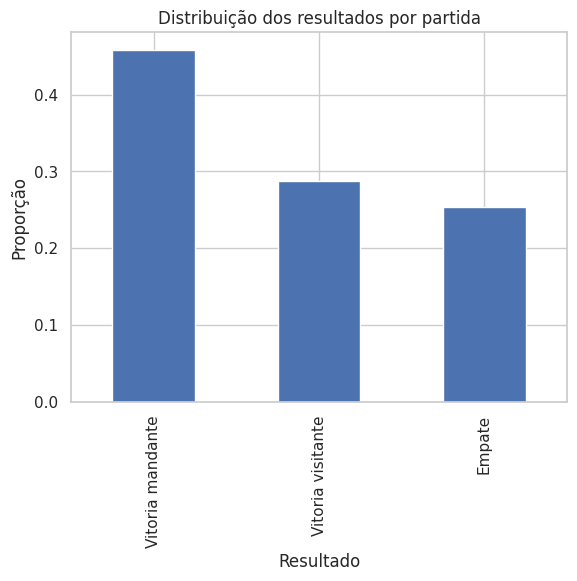

In [46]:
partidas_eda['resultado'].value_counts(
    normalize= True).plot(kind='bar')

plt.title('Distribuição dos resultados por partida')
plt.ylabel('Proporção')
plt.xlabel('Resultado')
plt.show()


In [47]:

partidas_eda = partidas_eda.rename(columns={
    "home_team_goal": "gols_mandante",
    "away_team_goal": "gols_visitante"
})


Mandante x Visitante gols

In [48]:
# Vendo quantos gols cada lado fez
partidas_eda[['gols_mandante', 'gols_visitante']].describe()

,gols_mandante,gols_visitante
count,25979.000000,25979.000000
mean,1.544594,1.160938
std,1.297158,1.142110
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,10.000000,9.000000


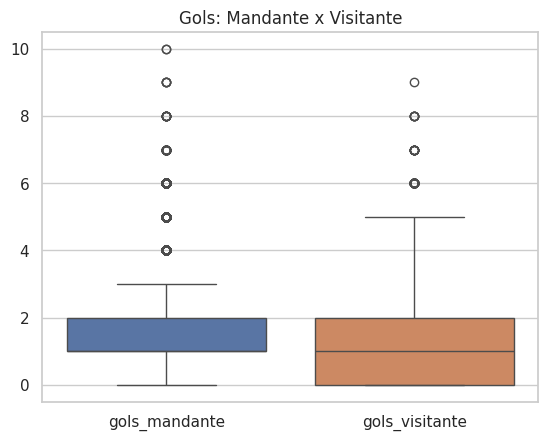

In [49]:
# comparando
sns.boxplot(
    data=partidas_eda[['gols_mandante', 'gols_visitante']]
)
plt.title('Gols: Mandante x Visitante')
plt.savefig("assets/mandante_x_visitante.png", dpi=150, bbox_inches="tight")
plt.show()

Analise temporal

In [50]:
# media de gols por temporada
media_gols_temporada = (
    partidas_eda.groupby('season')['gols_totais'].mean()
)
media_gols_temporada

,gols_totais
season,
2008/2009,2.607336
2009/2010,2.672446
2010/2011,2.683742
2011/2012,2.716460
2012/2013,2.772699
2013/2014,2.766821
2014/2015,2.675789
2015/2016,2.754660


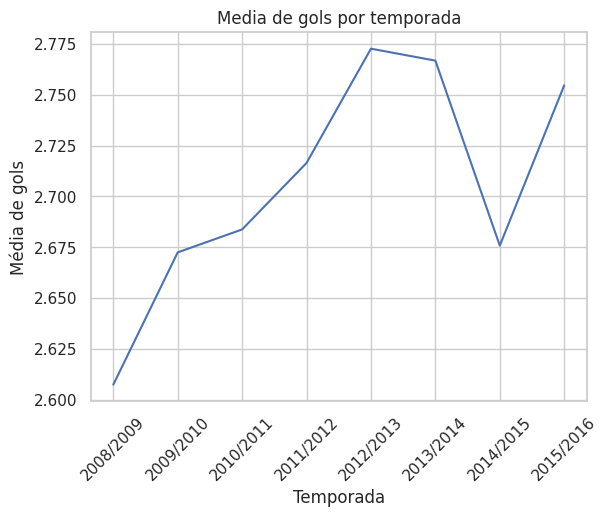

In [51]:
sns.lineplot(
    x=media_gols_temporada.index,
    y=media_gols_temporada.values
)
plt.title('Media de gols por temporada')
plt.xlabel('Temporada')
plt.ylabel('Média de gols')
plt.xticks(rotation=45)
plt.show()

Tabela de times

In [52]:
times = pd.read_sql("SELECT team_api_id, team_long_name FROM Team;",
                    conn)
times.head

<bound method NDFrame.head of      team_api_id      team_long_name
0           9987            KRC Genk
1           9993        Beerschot AC
2          10000    SV Zulte-Waregem
3           9994    Sporting Lokeren
4           9984   KSV Cercle Brugge
..           ...                 ...
294        10190       FC St. Gallen
295        10191             FC Thun
296         9777         Servette FC
297         7730  FC Lausanne-Sports
298         7896              Lugano

[299 rows x 2 columns]>

Mandante

In [53]:
partidas_times = partidas_eda.merge(
    times,
    left_on='home_team_api_id',
    right_on='team_api_id',
    how='left'
)

partidas_times = partidas_times.rename(columns={
    "team_long_name": "time_mandante"
})

partidas_times.head()

,season,date,home_team_api_id,away_team_api_id,gols_mandante,gols_visitante,ano,gols_totais,resultado,team_api_id,time_mandante
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate,9987,KRC Genk
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate,10000,SV Zulte-Waregem
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante,9984,KSV Cercle Brugge
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante,9991,KAA Gent
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante,7947,FCV Dender EH


Visitante

In [54]:

partidas_times = partidas_times.merge(
    times,
    left_on="away_team_api_id",
    right_on="team_api_id",
    how="left"
)

partidas_times = partidas_times.rename(columns={
    "team_long_name": "time_visitante"
})
partidas_times.head()

,season,date,home_team_api_id,away_team_api_id,gols_mandante,gols_visitante,ano,gols_totais,resultado,team_api_id_x,time_mandante,team_api_id_y,time_visitante
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate,9987,KRC Genk,9993,Beerschot AC
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate,10000,SV Zulte-Waregem,9994,Sporting Lokeren
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante,9984,KSV Cercle Brugge,8635,RSC Anderlecht
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante,9991,KAA Gent,9998,RAEC Mons
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante,7947,FCV Dender EH,9985,Standard de Liège


Gols marcados como mandante

In [55]:
gols_mandante = (
    partidas_times.groupby('time_mandante')['gols_mandante'].sum().sort_values(ascending= False)
)
gols_mandante.head(10)

,gols_mandante
time_mandante,
Real Madrid CF,505
FC Barcelona,495
Celtic,389
FC Bayern Munich,382
PSV,370
Manchester City,365
Ajax,360
FC Basel,344
Manchester United,338


Gols sofridos como mandante

In [56]:
gols_sofridos_mandante = (partidas_times.groupby('time_mandante')['gols_visitante'].sum().sort_values()
)
gols_sofridos_mandante.head(10)

,gols_visitante
time_mandante,
Amadora,15
Angers SCO,15
Uniao da Madeira,17
UD Las Palmas,17
FC Ingolstadt 04,18
Watford,19
Feirense,19
Termalica Bruk-Bet Nieciecza,19
Middlesbrough,20


Saldo de gols como Mandante

In [57]:
ranking_mandante = (
    partidas_times.groupby('time_mandante')[['gols_mandante', 'gols_visitante']].sum())

ranking_mandante['saldo_gols_mandante'] = (
    ranking_mandante['gols_mandante'] - ranking_mandante['gols_visitante']
)

ranking_mandante.sort_values('saldo_gols_mandante', ascending=False).head()

,gols_mandante,gols_visitante,saldo_gols_mandante
time_mandante,,,
FC Barcelona,495,101,394
Real Madrid CF,505,147,358
Celtic,389,88,301
FC Bayern Munich,382,96,286
Ajax,360,78,282



### Conclusão Parcial

Nesta etapa foi realizada a análise exploratória inicial da base de dados,
com foco nas partidas e no desempenho dos times atuando como mandantes.
Foram identificados padrões de distribuição de gols, vantagem do mandante
e diferenças claras entre desempenho ofensivo e defensivo dos times.



- Análise dos times: força ofensiva e defensiva

Gols como mandante

In [58]:

gols_marcados_casa = (
    partidas_times.groupby('time_mandante')['gols_mandante']
    .sum()
)
gols_marcados_casa


,gols_mandante
time_mandante,
1. FC Kaiserslautern,37
1. FC Köln,116
1. FC Nürnberg,108
1. FSV Mainz 05,171
AC Ajaccio,64
...,...
Xerez Club Deportivo,20
Zagłębie Lubin,116
Zawisza Bydgoszcz,43


- CRIANDO VITORIA COMO VARIAVEIS NUMERICAS

In [59]:
partidas_times['vitoria_mandante'] = (
    partidas_times['resultado'] == 'Vitoria mandante'
)

partidas_times['vitoria_visitante'] = (
    partidas_times['resultado'] == 'Vitoria visitante'
)

-  Vitórias como mandante

In [60]:
vitoria_mandante = (partidas_times.groupby('time_mandante')['vitoria_mandante']
                    .sum().sort_values(ascending=False))

vitoria_mandante.head(10)

,vitoria_mandante
time_mandante,
FC Barcelona,131
Real Madrid CF,129
Celtic,120
Manchester United,116
Manchester City,113
FC Bayern Munich,109
PSV,105
Juventus,105
Ajax,103


- Vitorias como visitantes

In [61]:
vitoria_visitante = (partidas_times.groupby('time_visitante')['vitoria_visitante']
                     .sum().sort_values(ascending=False))

vitoria_visitante.head(10)


,vitoria_visitante
time_visitante,
FC Barcelona,103
Real Madrid CF,99
Celtic,98
Juventus,84
FC Bayern Munich,84
SL Benfica,83
FC Porto,81
Ajax,78
FC Basel,77


### Força Ofensiva

- Media de gols por time em casa e fora

In [62]:
gols_casa = partidas_times.groupby('time_mandante')['gols_mandante'].mean()
gols_fora = partidas_times.groupby('time_visitante')['gols_visitante'].mean()

media_gols_time = (gols_casa + gols_fora) / 2

media_gols_time = media_gols_time.sort_values(ascending=False)

media_gols_time.head(10)

,0
time_mandante,
FC Barcelona,2.792763
Real Madrid CF,2.773026
FC Bayern Munich,2.400735
PSV,2.397059
Ajax,2.378676
SL Benfica,2.290323
Celtic,2.286184
FC Porto,2.181452
FC Basel,2.164336


### Força Defensiva

In [63]:
gols_sofridos_casa = partidas_times.groupby('time_mandante')['gols_visitante'].mean()
gols_sofridos_fora = partidas_times.groupby('time_visitante')['gols_mandante'].mean()

media_gols_sofridos = (gols_sofridos_casa + gols_sofridos_fora) / 2
media_gols_sofridos = media_gols_sofridos.sort_values()
media_gols_sofridos.head(10)

,0
time_mandante,
FC Porto,0.649194
Celtic,0.733553
Rangers,0.743421
SL Benfica,0.750000
FC Barcelona,0.763158
FC Bayern Munich,0.775735
Juventus,0.830596
Sporting CP,0.842742
Legia Warszawa,0.850000


### Criando Métrica complete

In [64]:

mandante = partidas_times[['time_mandante', 'gols_mandante', 'gols_visitante']].copy()

mandante.columns = ['time', 'gols_feitos', 'gols_sofridos']

visitante = partidas_times[['time_visitante', 'gols_visitante', 'gols_mandante']].copy()

visitante.columns = ['time', 'gols_feitos', 'gols_sofridos']


- junta Ataque + Defesa

In [65]:

dados_times = pd.concat([mandante, visitante])

desempenho_times = dados_times.groupby('time').agg({
    'gols_feitos': 'mean',
    'gols_sofridos': 'mean'
})

desempenho_times = desempenho_times.sort_values(by='gols_feitos', ascending=False)

desempenho_times.head(10)


,gols_feitos,gols_sofridos
time,,
FC Barcelona,2.792763,0.763158
Real Madrid CF,2.773026,1.000000
FC Bayern Munich,2.400735,0.775735
PSV,2.397059,1.080882
Ajax,2.378676,0.867647
SL Benfica,2.290323,0.750000
Celtic,2.286184,0.733553
FC Porto,2.181452,0.649194
FC Basel,2.164336,1.087413


- Saldo médio

In [66]:
desempenho_times['saldo_medio'] = (
    desempenho_times['gols_feitos'] -
    desempenho_times['gols_sofridos']
)

desempenho_times = desempenho_times.sort_values(by='saldo_medio', ascending=False)

desempenho_times.head(10)

,gols_feitos,gols_sofridos,saldo_medio
time,,,
FC Barcelona,2.792763,0.763158,2.029605
Real Madrid CF,2.773026,1.000000,1.773026
FC Bayern Munich,2.400735,0.775735,1.625000
Celtic,2.286184,0.733553,1.552632
SL Benfica,2.290323,0.750000,1.540323
FC Porto,2.181452,0.649194,1.532258
Ajax,2.378676,0.867647,1.511029
Rangers,2.131579,0.743421,1.388158
PSV,2.397059,1.080882,1.316176


Text(0, 0.5, 'Gols marcados (maior = melhor ataque)')

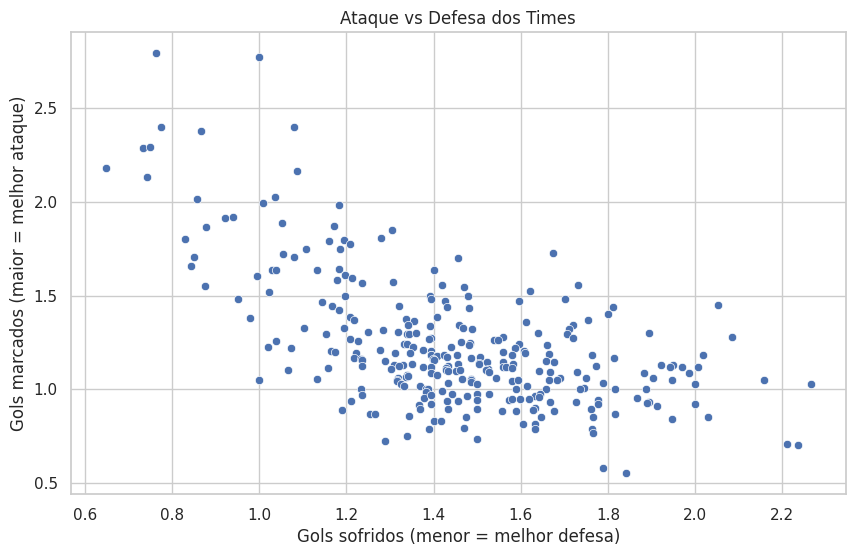

In [67]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=desempenho_times,
    x='gols_sofridos',
    y='gols_feitos'
)


plt.title('Ataque vs Defesa dos Times')
plt.xlabel('Gols sofridos (menor = melhor defesa)')
plt.ylabel('Gols marcados (maior = melhor ataque)')


- top 10 melhores

In [68]:

melhores_times = desempenho_times.sort_values(
    by='saldo_medio',
    ascending=False
)

melhores_times.head(10)


,gols_feitos,gols_sofridos,saldo_medio
time,,,
FC Barcelona,2.792763,0.763158,2.029605
Real Madrid CF,2.773026,1.000000,1.773026
FC Bayern Munich,2.400735,0.775735,1.625000
Celtic,2.286184,0.733553,1.552632
SL Benfica,2.290323,0.750000,1.540323
FC Porto,2.181452,0.649194,1.532258
Ajax,2.378676,0.867647,1.511029
Rangers,2.131579,0.743421,1.388158
PSV,2.397059,1.080882,1.316176


- Top 10 piores

In [69]:

piores_times = desempenho_times.sort_values(
    by='saldo_medio',
    ascending=True
)

piores_times.head(10)


,gols_feitos,gols_sofridos,saldo_medio
time,,,
FC Dordrecht,0.705882,2.235294,-1.529412
Pescara,0.710526,2.210526,-1.500000
AC Arles-Avignon,0.552632,1.842105,-1.289474
Tubize,1.029412,2.264706,-1.235294
Córdoba CF,0.578947,1.789474,-1.210526
FC Penafiel,0.852941,2.029412,-1.176471
Dunfermline Athletic,1.052632,2.157895,-1.105263
Cardiff City,0.842105,1.947368,-1.105263
Frosinone,0.921053,2.000000,-1.078947


### Player_Attributes

- Carregsndo e renomeando

In [70]:
atributos_jogadores = pd.read_sql("SELECT * FROM Player_Attributes", conn)

In [71]:
#inspeção inicial
atributos_jogadores.head()
atributos_jogadores.info()
atributos_jogadores.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183978 entries, 0 to 183977
Data columns (total 42 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   183978 non-null  int64  
 1   player_fifa_api_id   183978 non-null  int64  
 2   player_api_id        183978 non-null  int64  
 3   date                 183978 non-null  object 
 4   overall_rating       183142 non-null  float64
 5   potential            183142 non-null  float64
 6   preferred_foot       183142 non-null  object 
 7   attacking_work_rate  180748 non-null  object 
 8   defensive_work_rate  183142 non-null  object 
 9   crossing             183142 non-null  float64
 10  finishing            183142 non-null  float64
 11  heading_accuracy     183142 non-null  float64
 12  short_passing        183142 non-null  float64
 13  volleys              181265 non-null  float64
 14  dribbling            183142 non-null  float64
 15  curve            

,id,player_fifa_api_id,player_api_id,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
count,183978.00000,183978.000000,183978.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,181265.000000,...,181265.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000
mean,91989.50000,165671.524291,135900.617324,68.600015,73.460353,55.086883,49.921078,57.266023,62.429672,49.468436,...,57.873550,55.003986,46.772242,50.351257,48.001462,14.704393,16.063612,20.998362,16.132154,16.441439
std,53110.01825,53851.094769,136927.840510,7.041139,6.592271,17.242135,19.038705,16.488905,14.194068,18.256618,...,15.144086,15.546519,21.227667,21.483706,21.598778,16.865467,15.867382,21.452980,16.099175,17.198155
min,1.00000,2.000000,2625.000000,33.000000,39.000000,1.000000,1.000000,1.000000,3.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,45995.25000,155798.000000,34763.000000,64.000000,69.000000,45.000000,34.000000,49.000000,57.000000,35.000000,...,49.000000,45.000000,25.000000,29.000000,25.000000,7.000000,8.000000,8.000000,8.000000,8.000000
50%,91989.50000,183488.000000,77741.000000,69.000000,74.000000,59.000000,53.000000,60.000000,65.000000,52.000000,...,60.000000,57.000000,50.000000,56.000000,53.000000,10.000000,11.000000,12.000000,11.000000,11.000000
75%,137983.75000,199848.000000,191080.000000,73.000000,78.000000,68.000000,65.000000,68.000000,72.000000,64.000000,...,69.000000,67.000000,66.000000,69.000000,67.000000,13.000000,15.000000,15.000000,15.000000,15.000000
max,183978.00000,234141.000000,750584.000000,94.000000,97.000000,95.000000,97.000000,98.000000,97.000000,93.000000,...,97.000000,96.000000,96.000000,95.000000,95.000000,94.000000,93.000000,97.000000,96.000000,96.000000


Renomeando colunas importantes

In [72]:
atributos_jogadores = atributos_jogadores.rename(columns={
    'player_api_id' : 'id_jogador',
    'date' : 'data',
    'overall_rating' : 'nota_geral',
    'potential': 'potencial',
    'finishing': 'finalizacao',
    'short_passing': 'passe_curto',
    'long_passing': 'passe_longo',
    'dribbling': 'drible',
    'speed': 'velocidade'
})


Tratar data

In [73]:
atributos_jogadores['data'] = pd.to_datetime(atributos_jogadores['data'])

- Analise exploratória

<Axes: >

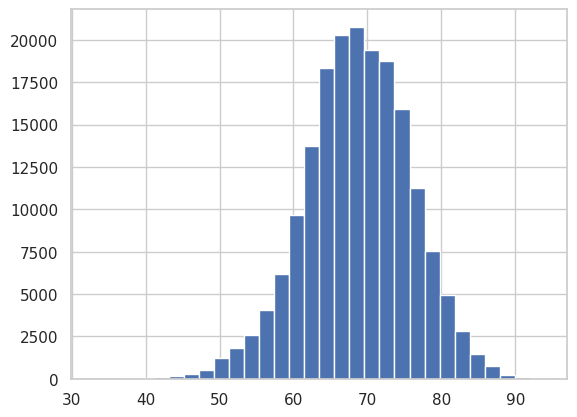

In [74]:
atributos_jogadores['nota_geral'].hist(bins=30)

- Top Melhores Jogadores

In [75]:
atributos_jogadores.sort_values(by='nota_geral', ascending= False).head(10)

,id,player_fifa_api_id,id_jogador,data,nota_geral,potencial,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
102496,102497,158023,30981,2013-02-15,94.0,97.0,left,high,medium,84.0,...,90.0,78.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102495,102496,158023,30981,2013-03-08,94.0,97.0,left,high,medium,84.0,...,90.0,78.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102494,102495,158023,30981,2013-03-22,94.0,97.0,left,high,medium,84.0,...,90.0,78.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102493,102494,158023,30981,2013-09-20,94.0,97.0,left,high,medium,84.0,...,90.0,76.0,25.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102499,102500,158023,30981,2011-08-30,94.0,96.0,left,high,medium,85.0,...,90.0,86.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102498,102499,158023,30981,2012-02-22,94.0,96.0,left,high,medium,85.0,...,90.0,78.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102497,102498,158023,30981,2012-08-31,94.0,96.0,left,high,medium,85.0,...,90.0,76.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102492,102493,158023,30981,2013-11-15,94.0,97.0,left,high,medium,84.0,...,90.0,76.0,25.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102491,102492,158023,30981,2014-04-25,94.0,97.0,left,medium,low,84.0,...,90.0,76.0,25.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102484,102485,158023,30981,2015-09-21,94.0,95.0,left,medium,low,80.0,...,90.0,74.0,13.0,23.0,21.0,6.0,11.0,15.0,14.0,8.0


Evolução ao longo do tempo

<Axes: xlabel='data'>

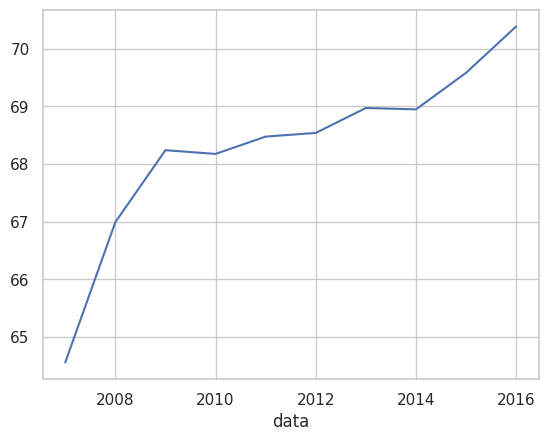

In [76]:
atributos_jogadores.groupby(atributos_jogadores['data'].dt.year)['nota_geral'].mean().plot()

Quais habilidades influenciam mais a nota:

In [77]:
# Correlação
atributos_jogadores[['nota_geral', 'potencial', 'finalizacao', 'passe_curto', 'drible']].corr()

,nota_geral,potencial,finalizacao,passe_curto,drible
nota_geral,1.000000,0.766757,0.329298,0.458361,0.354324
potencial,0.766757,1.000000,0.286684,0.382605,0.338675
finalizacao,0.329298,0.286684,1.000000,0.579365,0.784659
passe_curto,0.458361,0.382605,0.579365,1.000000,0.787994
drible,0.354324,0.338675,0.784659,0.787994,1.000000


Reduzir a tabela deixando uma linha por jogador

In [78]:
media_jogadores = atributos_jogadores.groupby('id_jogador').mean(numeric_only=True)


- Analise final

melhores jogadores

In [79]:
media_jogadores.sort_values(by='nota_geral', ascending=False).head(10)

,id,player_fifa_api_id,nota_geral,potencial,crossing,finalizacao,heading_accuracy,passe_curto,volleys,drible,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
id_jogador,,,,,,,,,,,,,,,,,,,,,
30981,102495.5,158023.0,92.192308,95.230769,83.346154,92.230769,69.269231,88.807692,87.538462,96.461538,...,90.269231,80.153846,18.769231,21.846154,20.115385,6.461538,12.653846,29.461538,15.076923,10.615385
30893,33343.0,20801.0,91.280000,93.480000,83.880000,91.120000,85.520000,82.280000,85.560000,92.640000,...,80.680000,83.600000,22.120000,30.840000,23.000000,7.480000,12.960000,28.440000,15.160000,12.760000
30924,58702.5,156616.0,88.458333,89.916667,85.166667,77.750000,48.541667,87.791667,82.041667,92.916667,...,86.958333,81.500000,18.708333,25.083333,26.000000,13.333333,8.541667,22.833333,9.500000,11.708333
30955,12786.0,41.0,88.320000,90.560000,83.720000,72.680000,55.320000,93.880000,74.000000,90.080000,...,92.920000,71.120000,58.240000,59.680000,56.000000,6.760000,14.720000,26.040000,14.520000,10.000000
35724,183683.0,41236.0,88.285714,90.047619,72.380952,90.000000,79.714286,84.238095,90.047619,89.380952,...,82.619048,88.000000,20.904762,43.809524,26.809524,12.666667,17.142857,24.714286,13.238095,15.142857
30834,16473.0,9014.0,87.840000,88.600000,82.480000,82.160000,51.560000,84.520000,84.480000,92.640000,...,82.400000,81.480000,26.240000,24.480000,25.240000,9.280000,10.680000,26.360000,8.760000,16.320000
39854,180720.5,10535.0,87.636364,88.363636,86.090909,73.590909,54.727273,95.181818,67.545455,82.363636,...,95.681818,78.227273,55.863636,64.545455,62.272727,5.727273,16.136364,30.227273,8.363636,11.409091
30829,178958.5,54050.0,87.222222,87.944444,78.472222,87.861111,78.583333,83.138889,88.694444,82.694444,...,84.166667,82.333333,30.750000,51.833333,37.777778,10.138889,12.000000,21.861111,9.527778,8.694444
30657,72601.5,5479.0,86.954545,88.227273,16.136364,14.454545,19.454545,21.000000,13.136364,19.590909,...,49.000000,43.090909,14.772727,14.772727,11.727273,89.863636,82.045455,69.409091,84.409091,90.954545


- Criando função de qualidade do time

In [80]:
dict_rating = media_jogadores['nota_geral'].to_dict()

def calcular_rating_time_fast(linha, colunas_jogadores):
    ratings = []

    for jogador in linha[colunas_jogadores]:
        if jogador in dict_rating:
            ratings.append(dict_rating[jogador])

    if ratings:
        return sum(ratings) / len(ratings)
    else:
        return None


In [81]:
# MANDANTE

colunas_mandante = [f'home_player_{i}' for i in range(1, 12)]

In [82]:
colunas_visitante = [f'away_player_{i}' for i in range(1, 12)]

- Criando Rating dos times

In [83]:
matches['rating_mandante'] = matches.apply(
    lambda x: calcular_rating_time_fast(x, colunas_mandante),
    axis=1
)

matches['rating_visitante'] = matches.apply(
    lambda x: calcular_rating_time_fast(x, colunas_visitante),
    axis=1
)

In [84]:
# Criando diferença

matches['diff_rating'] = (
    matches['rating_mandante'] - matches['rating_visitante']
)


In [85]:
matches['resultado'] = partidas_eda['resultado']

Analisando essencial


In [86]:
matches[['rating_mandante', 'rating_visitante', 'diff_rating']].describe()


,rating_mandante,rating_visitante,diff_rating
count,25221.000000,25221.000000,25221.000000
mean,70.316491,70.250031,0.066461
std,5.313683,5.300282,4.667178
min,54.891667,55.117105,-15.749146
25%,66.325161,66.282307,-2.890484
50%,70.824837,70.675511,0.086009
75%,73.746784,73.654903,3.034872
max,84.923247,85.051680,17.125228


In [87]:
matches.groupby('resultado')['diff_rating'].mean()

,diff_rating
resultado,
Empate,-0.373390
Vitoria mandante,1.907391
Vitoria visitante,-2.471856


### Tabela player

- Carregando e renomeando

In [88]:
jogadores = pd.read_sql("SELECT * FROM Player", conn)

In [89]:
jogadores = jogadores.rename(columns={
    'player_api_id': 'id_jogador',
    'player_name': 'nome_jogador',
    'birthday': 'data_nascimento',
    'height': 'altura',
    'weight': 'peso'
})

In [90]:

jogadores.head()
jogadores.info()
jogadores.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11060 entries, 0 to 11059
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  11060 non-null  int64  
 1   id_jogador          11060 non-null  int64  
 2   nome_jogador        11060 non-null  object 
 3   player_fifa_api_id  11060 non-null  int64  
 4   data_nascimento     11060 non-null  object 
 5   altura              11060 non-null  float64
 6   peso                11060 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 605.0+ KB


,id,id_jogador,player_fifa_api_id,altura,peso
count,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000
mean,5537.511392,156582.427215,165664.910488,181.867445,168.380289
std,3197.692647,160713.700624,58649.928360,6.369201,14.990217
min,1.000000,2625.000000,2.000000,157.480000,117.000000
25%,2767.750000,35555.500000,151889.500000,177.800000,159.000000
50%,5536.500000,96619.500000,184671.000000,182.880000,168.000000
75%,8306.250000,212470.500000,203883.250000,185.420000,179.000000
max,11075.000000,750584.000000,234141.000000,208.280000,243.000000


- Tratar data e criar idade

In [91]:
jogadores['data_nascimento'] = pd.to_datetime(jogadores['data_nascimento'])
data_base = pd.to_datetime('2013-01-01')

jogadores['idade'] = (
    data_base - jogadores['data_nascimento']
).dt.days / 365

- Analises principais

distribuição de idade

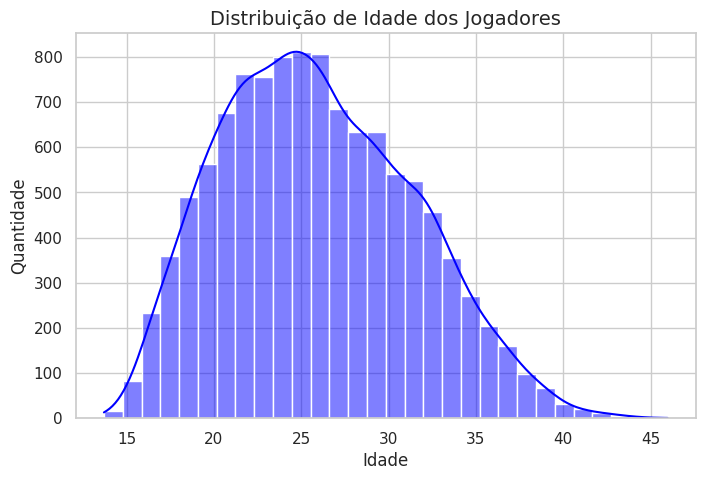

In [92]:
plt.figure(figsize=(8,5))

sns.histplot(
    jogadores['idade'],
    bins=30,
    kde=True,
    color='blue'
)

plt.title('Distribuição de Idade dos Jogadores', fontsize=14)
plt.xlabel('Idade')
plt.ylabel('Quantidade')
plt.savefig("assets/distribuicao_idade.png", dpi=150, bbox_inches="tight")
plt.show()


Altura

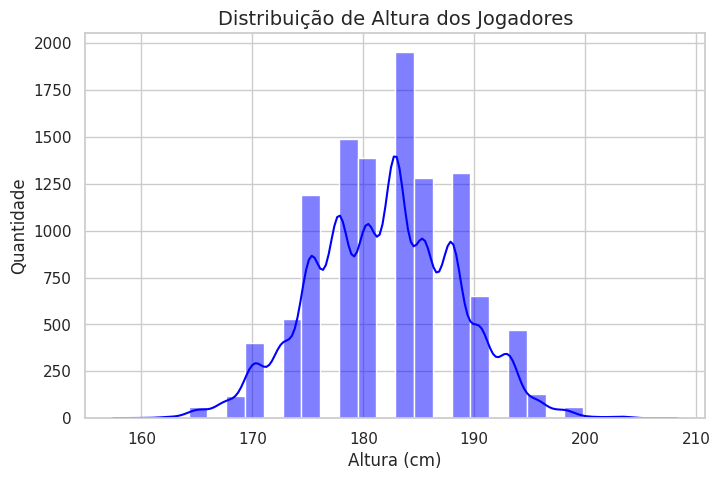

In [93]:
plt.figure(figsize=(8,5))

sns.histplot(
    jogadores['altura'],
    bins=30,
    kde=True,
    color='blue'
)

plt.title('Distribuição de Altura dos Jogadores', fontsize=14)
plt.xlabel('Altura (cm)')
plt.ylabel('Quantidade')
plt.savefig("assets/distribuicao_altura.png", dpi=150, bbox_inches="tight")
plt.show()

Peso

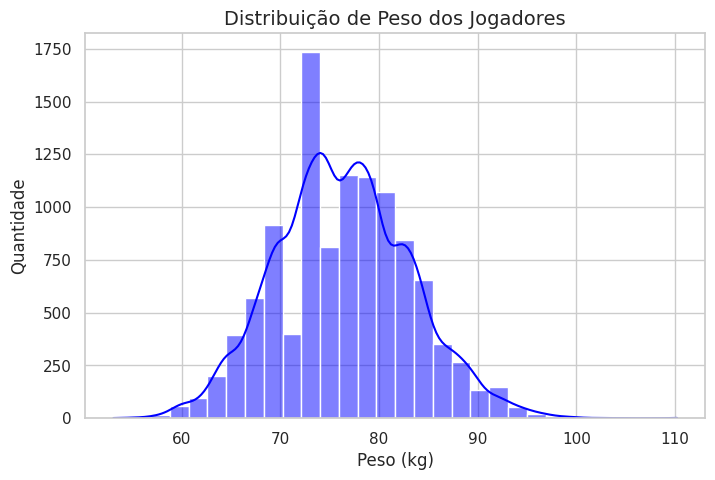

In [94]:
jogadores['peso_kg'] = jogadores['peso'] * 0.453592
plt.figure(figsize=(8,5))

sns.histplot(
    jogadores['peso_kg'],
    bins=30,
    kde=True,
    color='blue'
)

plt.title('Distribuição de Peso dos Jogadores', fontsize=14)
plt.xlabel('Peso (kg)')
plt.ylabel('Quantidade')
plt.savefig("assets/distribuicao_peso.png", dpi=150, bbox_inches="tight")
plt.show()

In [95]:
jogadores.sort_values(by='altura').head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
5446,5453,97226,Juan Quero,171126,1984-10-17,157.48,117,28.227397,53.070264
7247,7258,29587,Maxi Moralez,183895,1987-02-27,160.02,126,25.863014,57.152592
2609,2612,103139,Diego Buonanotte,170719,1988-04-19,160.02,123,24.720548,55.791816
3442,3446,215412,Fouad Rachid,201504,1991-11-15,162.56,126,21.145205,57.152592
2853,2857,278917,Edgar Salli,205753,1992-08-17,162.56,141,20.389041,63.956472


Estatísticas gerais

In [96]:
jogadores[['idade', 'altura', 'peso']].describe()

,idade,altura,peso
count,11060.000000,11060.000000,11060.000000
mean,25.926333,181.867445,168.380289
std,5.461620,6.369201,14.990217
min,13.701370,157.480000,117.000000
25%,21.739726,177.800000,159.000000
50%,25.504110,182.880000,168.000000
75%,29.816438,185.420000,179.000000
max,45.972603,208.280000,243.000000


IDENTIFICANDO OUTLIERS

In [97]:
jogadores['peso_kg'] = jogadores['peso'] * 0.453592


Jogadores muito altos

In [98]:
jogadores.sort_values(by='altura', ascending=False).head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
5901,5908,148325,Kristof van Hout,185306,1987-02-09,208.28,243,25.912329,110.222856
11027,11043,30850,Zeljko Kalac,51883,1972-12-16,203.20,209,40.071233,94.800728
1298,1301,150209,Bogdan Milic,189967,1987-11-24,203.20,216,25.123288,97.975872
8273,8285,41129,Paolo Acerbis,137130,1981-05-05,203.20,190,31.682192,86.182480
5797,5804,96465,Kevin Vink,193674,1984-07-30,203.20,194,28.443836,87.996848


Jogadores muito baixos

In [99]:
jogadores.sort_values(by='altura').head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
5446,5453,97226,Juan Quero,171126,1984-10-17,157.48,117,28.227397,53.070264
7247,7258,29587,Maxi Moralez,183895,1987-02-27,160.02,126,25.863014,57.152592
2609,2612,103139,Diego Buonanotte,170719,1988-04-19,160.02,123,24.720548,55.791816
3442,3446,215412,Fouad Rachid,201504,1991-11-15,162.56,126,21.145205,57.152592
2853,2857,278917,Edgar Salli,205753,1992-08-17,162.56,141,20.389041,63.956472


jogadores muito pesados

In [100]:
jogadores.sort_values(by='peso_kg', ascending=False).head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
10297,10313,27313,Tim Wiese,53012,1981-12-17,193.04,243,31.063014,110.222856
5901,5908,148325,Kristof van Hout,185306,1987-02-09,208.28,243,25.912329,110.222856
4879,4884,5044,Jeroen Verhoeven,137692,1980-04-30,198.12,227,32.695890,102.965384
4408,4412,27267,Ishmael Miller,169725,1987-03-05,193.04,225,25.846575,102.058200
1595,1598,101584,Cassio,167958,1987-06-06,195.58,220,25.591781,99.790240


Correlação simples

In [101]:
jogadores[['idade', 'altura', 'peso']].corr()

,idade,altura,peso
idade,1.000000,0.061582,0.177161
altura,0.061582,1.000000,0.766626
peso,0.177161,0.766626,1.000000


In [102]:
jogadores[['idade', 'altura', 'peso_kg']].isna().sum()

,0
idade,0
altura,0
peso_kg,0


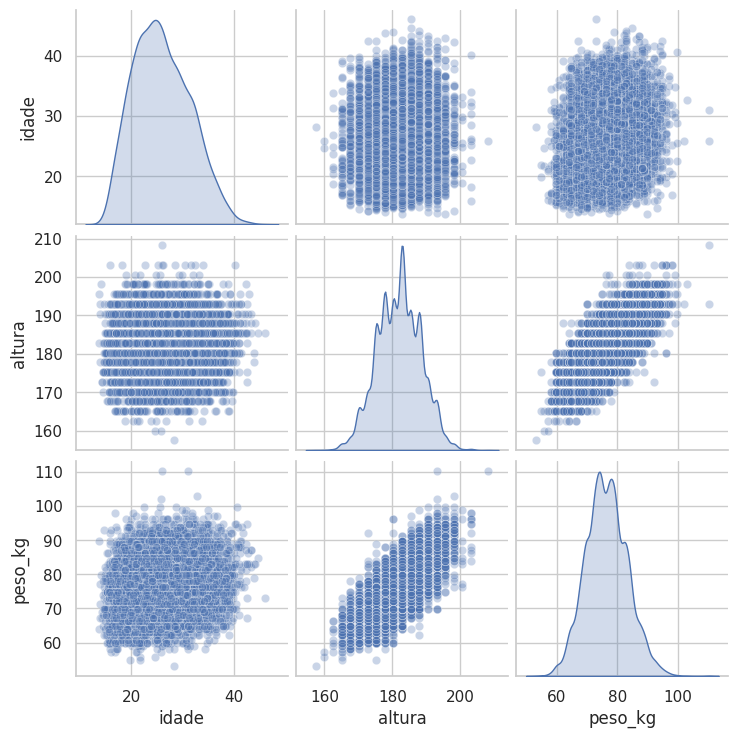

In [103]:
sns.pairplot(
    jogadores[['idade', 'altura', 'peso_kg']],
    diag_kind='kde',
    plot_kws={'alpha':0.3}
)

### Tabela League

In [104]:
ligas = pd.read_sql("SELECT * FROM League", conn)

In [105]:
ligas.head()
ligas.info

<bound method DataFrame.info of        id  country_id                      name
0       1           1    Belgium Jupiler League
1    1729        1729    England Premier League
2    4769        4769            France Ligue 1
3    7809        7809     Germany 1. Bundesliga
4   10257       10257             Italy Serie A
5   13274       13274    Netherlands Eredivisie
6   15722       15722        Poland Ekstraklasa
7   17642       17642  Portugal Liga ZON Sagres
8   19694       19694   Scotland Premier League
9   21518       21518           Spain LIGA BBVA
10  24558       24558  Switzerland Super League>

In [106]:
ligas.nunique()

,0
id,11
country_id,11
name,11


- Ligando nomes

In [107]:
ligas['name'].value_counts()

,count
name,
Belgium Jupiler League,1
England Premier League,1
France Ligue 1,1
Germany 1. Bundesliga,1
Italy Serie A,1
Netherlands Eredivisie,1
Poland Ekstraklasa,1
Portugal Liga ZON Sagres,1
Scotland Premier League,1


- Relação com paises

In [108]:
paises = pd.read_sql("SELECT * FROM Country", conn)

Juntando as tabelas

In [109]:
ligas = ligas.merge(paises, left_on='country_id', right_on='id')


In [110]:
ligas = ligas.rename(columns={
    'name_x': 'liga',
    'name_y': 'pais'})


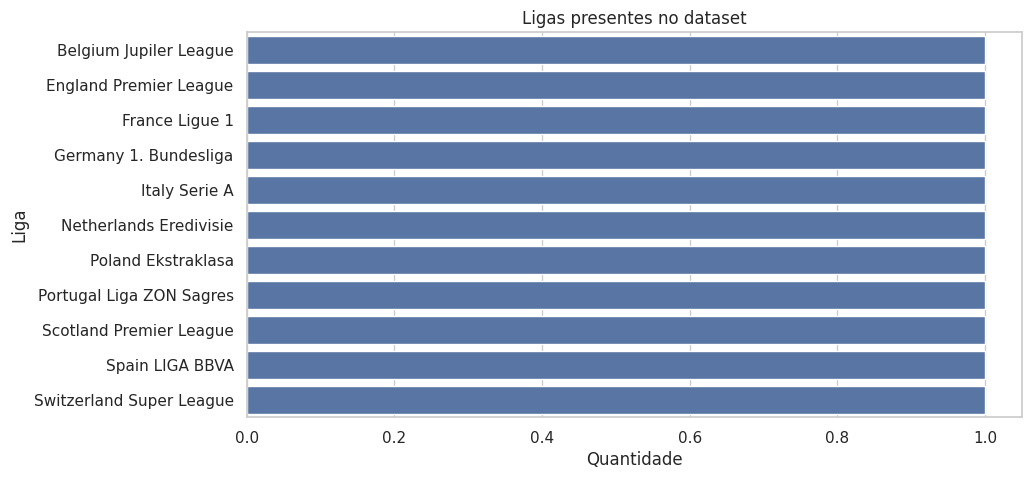

In [111]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=ligas['liga'],
    order=ligas['liga'].value_counts().index
    )

plt.title('Ligas presentes no dataset')

plt.xlabel('Quantidade')
plt.ylabel('Liga')
plt.show()



Vendo quantas ligas por pais

In [112]:
jogadores.sort_values(by='altura').head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
5446,5453,97226,Juan Quero,171126,1984-10-17,157.48,117,28.227397,53.070264
7247,7258,29587,Maxi Moralez,183895,1987-02-27,160.02,126,25.863014,57.152592
2609,2612,103139,Diego Buonanotte,170719,1988-04-19,160.02,123,24.720548,55.791816
3442,3446,215412,Fouad Rachid,201504,1991-11-15,162.56,126,21.145205,57.152592
2853,2857,278917,Edgar Salli,205753,1992-08-17,162.56,141,20.389041,63.956472


- Trazendo essas informações para os jogos

In [113]:
matches = matches.drop(
    columns=['liga_x', 'liga_y', 'pais_x', 'pais_y'],
    errors='ignore'
)

In [114]:
matches.columns

Index(['id', 'country_id', 'league_id', 'season', 'stage', 'date',
       'match_api_id', 'home_team_api_id', 'away_team_api_id',
       'home_team_goal',
       ...
       'GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA', 'rating_mandante',
       'rating_visitante', 'diff_rating', 'resultado'],
      dtype='object', length=119)

Quantidade de jogos por liga

Essa análise será realizada após a junção da tabela de partidas com as informações de liga.

Criando variaveis de gols totais

In [115]:

matches['gols_totais'] = (
    matches['home_team_goal'] + matches['away_team_goal']
)


In [116]:
matches[['home_team_goal', 'away_team_goal', 'gols_totais']].head()

,home_team_goal,away_team_goal,gols_totais
0,1,1,2
1,0,0,0
2,0,3,3
3,5,0,5
4,1,3,4


- Média de gols por liga

In [117]:
media_gols_liga = matches.groupby('league_id')['gols_totais'].mean()
media_gols_liga = media_gols_liga.sort_values(ascending=False)
media_gols_liga

,gols_totais
league_id,
13274,3.080882
24558,2.929677
7809,2.901552
1,2.801505
21518,2.767105
1729,2.710526
19694,2.633772
10257,2.616838
17642,2.534600


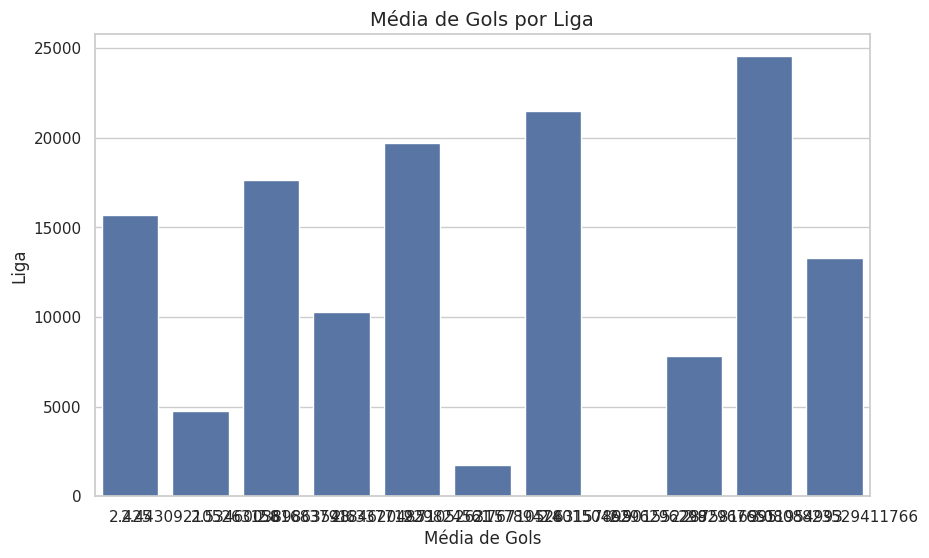

In [118]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=media_gols_liga.values,
    y=media_gols_liga.index
)

plt.title('Média de Gols por Liga', fontsize=14)
plt.xlabel('Média de Gols')
plt.ylabel('Liga')
plt.savefig("assets/media_gols_liga.png", dpi=150, bbox_inches="tight")
plt.show()

- ANÁLISE CASA vs FORA

In [119]:
media_gols = matches.groupby('league_id')[[
    'home_team_goal',
    'away_team_goal'
]].mean()

media_gols

,home_team_goal,away_team_goal
league_id,,
1,1.609375,1.192130
1729,1.550987,1.159539
4769,1.402961,1.040132
7809,1.626634,1.274918
10257,1.500829,1.116009
13274,1.779820,1.301062
15722,1.394792,1.030208
17642,1.408382,1.126218
19694,1.429276,1.204496


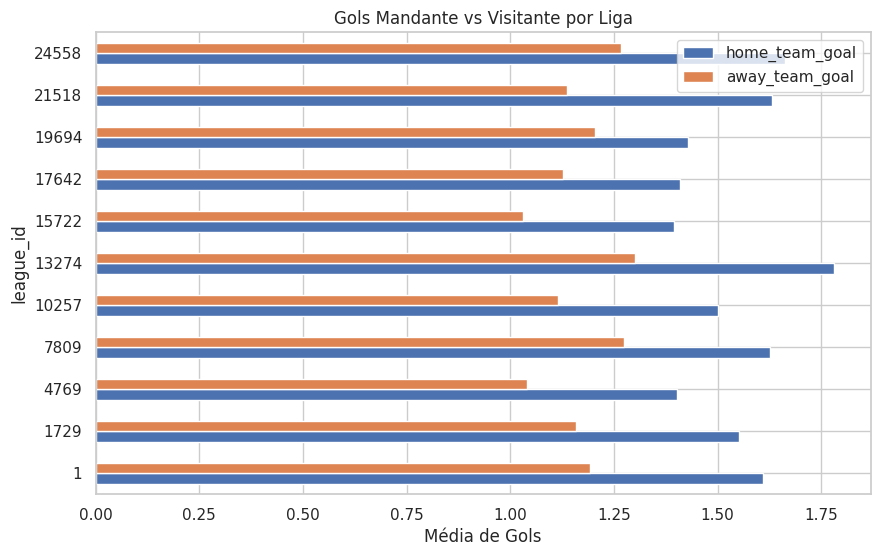

In [120]:

media_gols.plot(kind='barh', figsize=(10,6))

plt.title('Gols Mandante vs Visitante por Liga')
plt.xlabel('Média de Gols')
plt.savefig("assets/mandante_x_visitante_liga.png", dpi=150, bbox_inches="tight")
plt.show()


### Tabela Country

In [121]:
paises = pd.read_sql("SELECT * FROM Country", conn)

In [122]:
paises.head()
paises.info()
paises.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      11 non-null     int64 
 1   name    11 non-null     object
dtypes: int64(1), object(1)
memory usage: 308.0+ bytes


,0
id,11
name,11


Renomeando

In [123]:
jogadores.sort_values(by='altura').head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
5446,5453,97226,Juan Quero,171126,1984-10-17,157.48,117,28.227397,53.070264
7247,7258,29587,Maxi Moralez,183895,1987-02-27,160.02,126,25.863014,57.152592
2609,2612,103139,Diego Buonanotte,170719,1988-04-19,160.02,123,24.720548,55.791816
3442,3446,215412,Fouad Rachid,201504,1991-11-15,162.56,126,21.145205,57.152592
2853,2857,278917,Edgar Salli,205753,1992-08-17,162.56,141,20.389041,63.956472


quantidade de jogos por pais

In [124]:
quantidade_jogos_pais = matches['country_id'].value_counts()
quantidade_jogos_pais

,count
country_id,
1729,3040
4769,3040
21518,3040
10257,3017
13274,2448
7809,2448
17642,2052
15722,1920
19694,1824


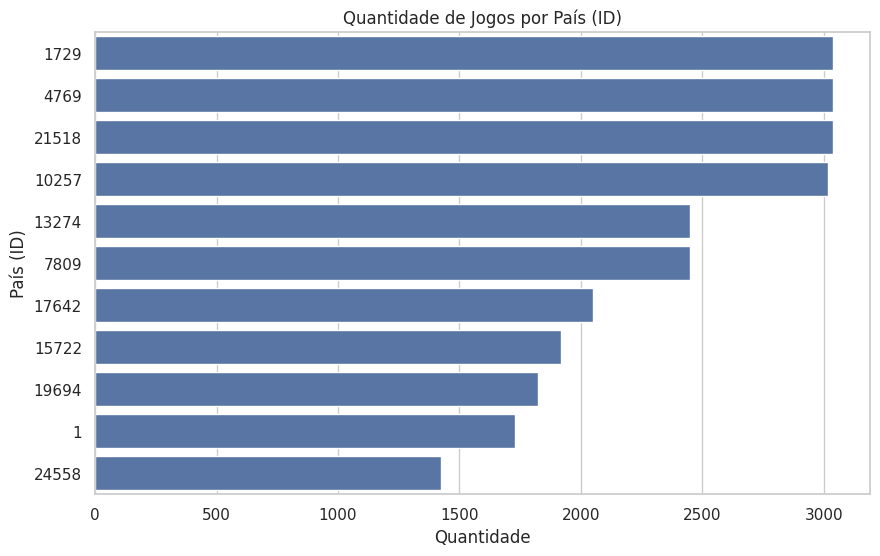

In [125]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=matches['country_id'],
    order=matches['country_id'].value_counts().index
)

plt.title('Quantidade de Jogos por País (ID)')
plt.xlabel('Quantidade')
plt.ylabel('País (ID)')

plt.show()

Média de gols por pais

In [126]:
media_gols_pais = matches.groupby('country_id')['gols_totais'].mean()

media_gols_pais = media_gols_pais.sort_values(ascending=False)

media_gols_pais

,gols_totais
country_id,
13274,3.080882
24558,2.929677
7809,2.901552
1,2.801505
21518,2.767105
1729,2.710526
19694,2.633772
10257,2.616838
17642,2.534600


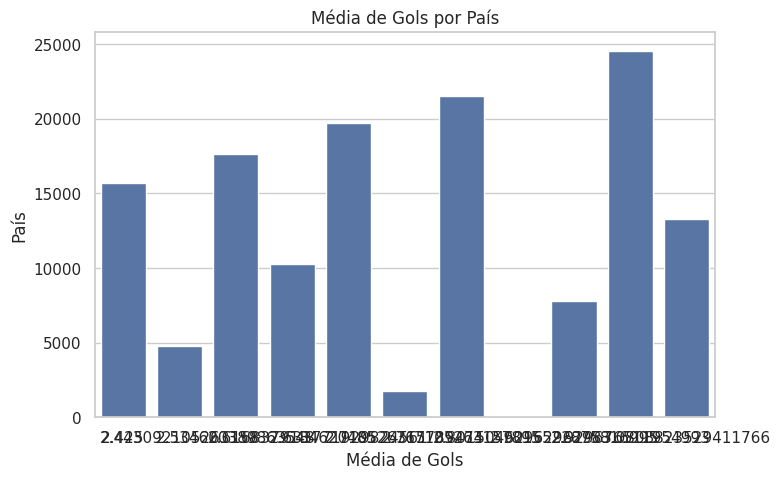

In [127]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=media_gols_pais.values,
    y=media_gols_pais.index
)

plt.title('Média de Gols por País')
plt.xlabel('Média de Gols')
plt.ylabel('País')

plt.show()

### Tabela Team

In [128]:
times = pd.read_sql("SELECT * FROM Team", conn)

In [129]:

times.head()
times.info()
times.nunique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                299 non-null    int64  
 1   team_api_id       299 non-null    int64  
 2   team_fifa_api_id  288 non-null    float64
 3   team_long_name    299 non-null    object 
 4   team_short_name   299 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.8+ KB


,0
id,299
team_api_id,299
team_fifa_api_id,285
team_long_name,296
team_short_name,259


Renomeando

In [130]:
times = times.rename(columns={
    'team_api_id': 'id_time',
    'team_long_name': 'nome_time'
})

In [131]:
# Ver quantos times existem
times['nome_time'].nunique()

296

In [132]:
times['nome_time'].value_counts().head()

,count
nome_time,
Polonia Bytom,2
Widzew Łódź,2
Royal Excel Mouscron,2
Górnik Łęczna,1
Zawisza Bydgoszcz,1


Conectando com matches

In [133]:
matches = matches.merge(
    times[['id_time', 'nome_time']],
    left_on='home_team_api_id',
    right_on='id_time',
    how='left'
)

In [134]:
# renomear
matches = matches.rename(columns={
    'nome_time': 'time_mandante'
})

In [135]:
# times visitantes
matches = matches.merge(
    times[['id_time', 'nome_time']],
    left_on='away_team_api_id',
    right_on='id_time',
    how='left'
)

In [136]:
matches = matches.rename(columns={
    'nome_time': 'time_visitante'
})

Fazendo a limpeza

In [137]:
matches = matches.drop(columns=['id_time'], errors='ignore')

In [138]:
matches = matches.drop(columns=['id_time_x', 'id_time_y'], errors='ignore')

In [139]:
matches[['time_mandante', 'time_visitante']].head()

,time_mandante,time_visitante
0,KRC Genk,Beerschot AC
1,SV Zulte-Waregem,Sporting Lokeren
2,KSV Cercle Brugge,RSC Anderlecht
3,KAA Gent,RAEC Mons
4,FCV Dender EH,Standard de Liège


 - Analise simples

Times com mais jogos mandante

In [140]:
matches['time_mandante'].value_counts().head(10)

,count
time_mandante,
FC Barcelona,152
Málaga CF,152
Getafe CF,152
LOSC Lille,152
Tottenham Hotspur,152
Girondins de Bordeaux,152
Real Madrid CF,152
Olympique Lyonnais,152
Stade Rennais FC,152


Times com mais jogos visitantes

In [141]:
matches['time_visitante'].value_counts().head(10)

,count
time_visitante,
Motherwell,153
Athletic Club de Bilbao,152
Stoke City,152
Everton,152
Chelsea,152
Sunderland,152
Valencia CF,152
Aston Villa,152
Olympique Lyonnais,152


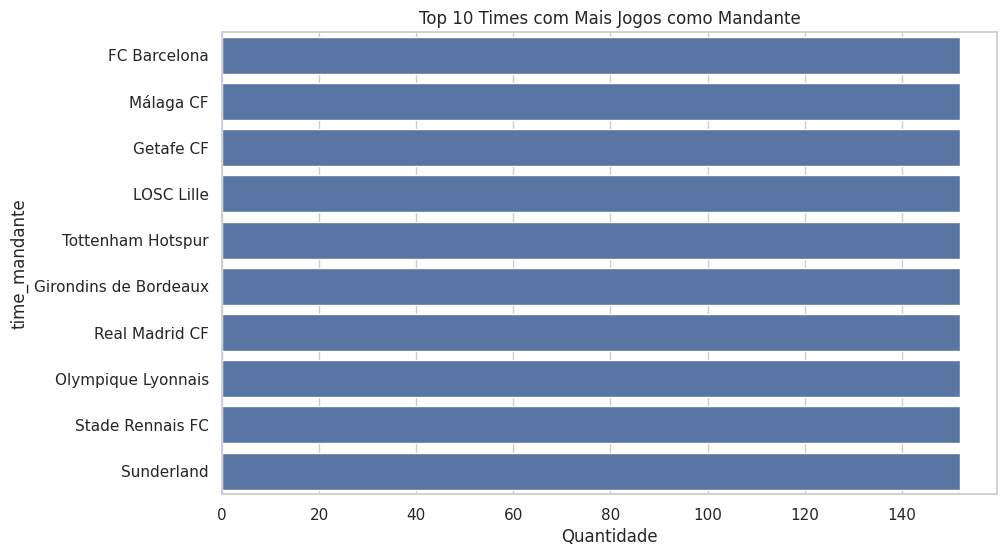

In [142]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=matches['time_mandante'],
    order=matches['time_mandante'].value_counts().head(10).index
)

plt.title('Top 10 Times com Mais Jogos como Mandante')
plt.xlabel('Quantidade')
plt.savefig("assets/top10_times_mandantes.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise com Hipóteses

- Hipótese 1

Vantagem do mandante

In [143]:
matches['vitoria_mandante'] = (
    matches['resultado'] == 'Vitoria mandante'
)

percentual_vitoria_casa = matches['vitoria_mandante'].mean()

percentual_vitoria_casa

np.float64(0.45871665576042187)


Foi analisada a proporção de vitórias dos times jogando em casa.

Os resultados indicam que o time mandante apresenta maior probabilidade de vitória, reforçando a existência de vantagem de jogar em casa.

Feature correspondente: vitoria_mandante


- Hipótese 2

Qualidade do time influencia a vitória

In [144]:
matches['vitoria_mandante_bin'] = (
    matches['resultado'] == 'Vitoria mandante'
)

media_rating = matches.groupby('vitoria_mandante_bin')['rating_mandante'].mean()

media_rating

,rating_mandante
vitoria_mandante_bin,
False,69.420253
True,71.377312



Foi analisado o rating médio dos jogadores em partidas com vitória e sem vitória.

Conseguimos observar que equipes vencedoras apresentam um rating médio superior, mostrando que a qualidade dos jogadores influencia positivamente as chances de vitória.

Feature correspondente: rating_mandante


- Hipótese 3

Diferença de qualidade entre times

In [145]:
media_diff = matches.groupby('vitoria_mandante_bin')['diff_rating'].mean()

media_diff

,diff_rating
vitoria_mandante_bin,
False,-1.488857
True,1.907391



Foi analisada a diferença de rating entre os times nas partidas.

Os resultados mostram que quando o time mandante vence, a diferença de rating é positiva, indicando superioridade técnica.

Porém, quando não vence a diferença tende a ser negativa.

Isso mostra que a diferença de qualidade entre os times é um fator determinante para o resultado.

Feature correspondente: diff_rating

- Hipótese 4

Ataque influencia o resultado



In [146]:

media_gols = matches.groupby('vitoria_mandante_bin')['home_team_goal'].mean()

media_gols


,home_team_goal
vitoria_mandante_bin,
False,0.782321
True,2.444071


Foi analisada a média de gols marcados pelo time mandante em vitórias e não vitórias.

Percebemos que partidas com vitória apresentam maior número de gols, indicando que o desempenho ofensivo está diretamente relacionado ao sucesso.

Feature correspondente: home_team_goal

- Hipótese 5

Defesa reduz derrota

In [147]:

matches['derrota_mandante'] = (
    matches['resultado'] == 'Vitoria visitante')

media_gols_sofridos = matches.groupby('derrota_mandante')['away_team_goal'].mean()
media_gols_sofridos

,away_team_goal
derrota_mandante,
False,0.701345
True,2.300563



Foi analisado o número de gols sofridos em partidas com derrota e sem derrota.

Os resultados indicam que equipes que sofrem mais gols apresentam maior probabilidade de derrota, reforçando a importância de uma equipe com boa defesa.

Feature correspondente: away_team_goal


## Hipóteses Avançadas

- Hipótese 1

Balanço ofensivo vs defensivo

In [148]:
# usando tabela que você já criou
correlacao = desempenho_times['gols_feitos'].corr(desempenho_times['gols_sofridos'])

correlacao

np.float64(-0.6075957253668325)

Aqui temos um valor de -0.60 negativo...
Isso quebra uma expectativa de "Times que atacam sofrem mais gols"
e nesse cenário times ofensivos também tendem a ser bons defensivamente

- Hipótese 2

Equilibrio do time

In [149]:
desempenho_times['equilibrio'] = abs(
    desempenho_times['gols_feitos'] - desempenho_times['gols_sofridos'])
top_times = desempenho_times.sort_values('saldo_medio', ascending=False)
top_times[['gols_feitos', 'gols_sofridos', 'equilibrio']].head(10)

,gols_feitos,gols_sofridos,equilibrio
time,,,
FC Barcelona,2.792763,0.763158,2.029605
Real Madrid CF,2.773026,1.000000,1.773026
FC Bayern Munich,2.400735,0.775735,1.625000
Celtic,2.286184,0.733553,1.552632
SL Benfica,2.290323,0.750000,1.540323
FC Porto,2.181452,0.649194,1.532258
Ajax,2.378676,0.867647,1.511029
Rangers,2.131579,0.743421,1.388158
PSV,2.397059,1.080882,1.316176


Aqui conseguimos ver que times equilibrados performam melhor do que times extremos

Vemos também a diferença entre gols marcados e sofridos para avaliar o equilíbrio das equipes.

Possível feature: equilibrio




- Hipótese 3

Efeito da diferença da qualidade

In [150]:

matches['faixa_diff'] = pd.cut(matches['diff_rating'], bins=5)

vitoria_por_faixa = matches.groupby('faixa_diff')['vitoria_mandante_bin'].mean()

vitoria_por_faixa


/tmp/ipykernel_895/637970201.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vitoria_por_faixa = matches.groupby('faixa_diff')['vitoria_mandante_bin'].mean()


,vitoria_mandante_bin
faixa_diff,
"(-15.782, -9.174]",0.089235
"(-9.174, -2.599]",0.254334
"(-2.599, 3.975]",0.472263
"(3.975, 10.55]",0.711853
"(10.55, 17.125]",0.901786



Vemos aqui, que aumentar a diferença de qualidades dos times nem sempre aumenta as chances de vitória na mesma proporção, em diferenças muito grandes esse impacto tende a diminuir

Possível feature: faixa_diff_rating


- Hipótese 4

Consistência dos times

In [151]:
variancia_gols = dados_times.groupby('time')['gols_feitos'].std()
variancia_gols = variancia_gols.sort_values()
variancia_gols.head(10)

,gols_feitos
time,
Córdoba CF,0.642275
Birmingham City,0.739250
Le Havre AC,0.740996
FC Dordrecht,0.759961
Amadora,0.776079
DSC Arminia Bielefeld,0.783634
Trofense,0.791478
Middlesbrough,0.794719
Pescara,0.802290


Foi analisada a variabilidade do número de gols marcados por cada equipe.

Conseguimos ver que times mais consistentes são mais previsiveis, ou seja, não variam muito, mostrando maior estabilidade ao longo das partidas.

Possível feature: variancia_gols

- Hipótese 5

Jogos equilibrados

In [152]:
jogos_equilibrados = matches[abs(matches['diff_rating']) < 5]
jogos_desequilibrados = matches[abs(matches['diff_rating']) >= 5]

empate_eq = (jogos_equilibrados['resultado'] == 'Empate').mean()
empate_deseq = (jogos_desequilibrados['resultado'] == 'Empate').mean()

empate_eq, empate_deseq

(np.float64(0.27478299331011224), np.float64(0.20100925147182505))

Foi analisada a taxa de empates em jogos equilibrados e desequilibrados.

Quando os times têm nível parecido fica mais difícil decidir um vencedor, ou seja, mais chances de empate.

Possível feature: jogo_equilibrado

# Hipóteses relacionadas à qualidade dos jogadores

In [153]:

pd.read_sql("""
SELECT name FROM sqlite_master
WHERE type='table';
""", conn)



,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


In [154]:

players = pd.read_sql("SELECT * FROM Player", conn)

player_attributes = pd.read_sql("SELECT * FROM Player_Attributes", conn)


In [155]:

players.head()
player_attributes.head()




,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


- Hipótese 1

Quais habilidades influenciam mais gols

In [156]:

atributos = [
    'finishing',
    'shot_power',
    'positioning',
    'long_shots',
    'sprint_speed',
    'acceleration',
    'stamina',
    'strength'
]



 correlação com overall_rating

In [157]:

player_attributes_latest = player_attributes.sort_values('date').drop_duplicates(
    subset='player_api_id',
    keep='last'
)


In [158]:

correlacoes = player_attributes_latest[atributos + ['overall_rating']].corr()
correlacoes





,finishing,shot_power,positioning,long_shots,sprint_speed,acceleration,stamina,strength,overall_rating
finishing,1.000000,0.745443,0.849279,0.822390,0.480039,0.499501,0.369570,-0.083443,0.262909
shot_power,0.745443,1.000000,0.745939,0.851168,0.442824,0.432396,0.519434,0.136950,0.349636
positioning,0.849279,0.745939,1.000000,0.804619,0.540062,0.561539,0.497685,-0.089076,0.284104
long_shots,0.822390,0.851168,0.804619,1.000000,0.452124,0.477598,0.479466,-0.038956,0.327049
sprint_speed,0.480039,0.442824,0.540062,0.452124,1.000000,0.910952,0.570277,-0.194758,0.190270
acceleration,0.499501,0.432396,0.561539,0.477598,0.910952,1.000000,0.550147,-0.293412,0.176767
stamina,0.369570,0.519434,0.497685,0.479466,0.570277,0.550147,1.000000,0.137065,0.243654
strength,-0.083443,0.136950,-0.089076,-0.038956,-0.194758,-0.293412,0.137065,1.000000,0.230111
overall_rating,0.262909,0.349636,0.284104,0.327049,0.190270,0.176767,0.243654,0.230111,1.000000



Aqui analisei a correlação entre atributos técnicos dos jogadores.

Os resultados mostram forte relação entre habilidades ofensivas como finalização, drible e passe, indicando que jogadores de alto nível tendem a apresentar um conjunto amplo de competências técnicas.

Esse comportamento sugere que o desempenho individual é resultado da combinação de múltiplas habilidades, e não apenas de um único atributo isolado.


- Hipótese 2

Quais habilidades mais importam

In [159]:
correlacoes['overall_rating'].sort_values(ascending=False)

,overall_rating
overall_rating,1.000000
shot_power,0.349636
long_shots,0.327049
positioning,0.284104
finishing,0.262909
stamina,0.243654
strength,0.230111
sprint_speed,0.190270
acceleration,0.176767


Os resultados indicam que habilidades técnicas e ofensivas possuem maior influência no desempenho dos jogadores, enquanto atributos físicos apresentam impacto secundário.

Isso mostra que para ter destaque está relacionado mais a capacidade técnica do que apenas a condição fisica

- Hipótese 3

Top jogadores

In [160]:

top_jogadores = player_attributes_latest.sort_values(
    by='overall_rating',
    ascending=False
).head(20)


Juntando nomes

In [161]:

top_jogadores = top_jogadores.merge(
    players[['player_api_id', 'player_name']],
    on='player_api_id'
)


MELHOR HABILIDADE

In [162]:

habilidades = [
    'finishing',
    'shot_power',
    'positioning',
    'dribbling',
    'short_passing',
    'long_passing',
    'sprint_speed',
    'stamina',
    'strength'
]

top_jogadores['melhor_habilidade'] = top_jogadores[habilidades].idxmax(axis=1)


In [163]:

top_jogadores = player_attributes_latest.sort_values(
    by='overall_rating',
    ascending=False
)


In [164]:

top_jogadores = top_jogadores.merge(
    players[['player_api_id', 'player_name']],
    on='player_api_id'
)


In [165]:
top_jogadores[['player_name', 'overall_rating']].head(10)

,player_name,overall_rating
0,Lionel Messi,94.0
1,Cristiano Ronaldo,93.0
2,Neymar,90.0
3,Luis Suarez,90.0
4,Manuel Neuer,90.0
5,Zlatan Ibrahimovic,89.0
6,Arjen Robben,89.0
7,Thiago Silva,88.0
8,Mesut Oezil,88.0
9,Andres Iniesta,88.0


- Hipótese 4

Agrupamento de habilidades

Em vez de olhar habilidade isolada, analisar tipos de jogador

In [166]:
player_attributes_latest['ofensivo'] = player_attributes_latest[
    ['finishing', 'shot_power', 'positioning']
].mean(axis=1)

player_attributes_latest['tecnico'] = player_attributes_latest[
    ['dribbling', 'short_passing', 'long_passing']
].mean(axis=1)

player_attributes_latest['fisico'] = player_attributes_latest[
    ['stamina', 'strength', 'acceleration']
].mean(axis=1)

player_attributes_latest['defensivo'] = player_attributes_latest[
    ['marking', 'standing_tackle', 'sliding_tackle']
].mean(axis=1)

Analisando impacto

In [167]:

player_attributes_latest[
    ['ofensivo', 'tecnico', 'fisico', 'defensivo', 'overall_rating']
].corr()['overall_rating'].sort_values(ascending=False)


,overall_rating
overall_rating,1.000000
tecnico,0.395194
fisico,0.324704
ofensivo,0.320456
defensivo,0.141543



As habilidades foram agrupadas em categorias: ofensiva, técnica, física e defensiva.

Os resultados mostram que atributos ofensivos e técnicos apresentam maior correlação com o rating geral dos jogadores, indicando maior impacto no desempenho.

Isso mostra que o sucesso individual está mais associado à qualidade técnica e ofensiva do que a atributos físicos ou defensivos isolados.


- Hipótese 5

Perfil dos melhores jogadores

In [168]:
player_attributes_latest['ofensivo'] = player_attributes_latest[
    ['finishing', 'shot_power', 'positioning']
].mean(axis=1)

player_attributes_latest['tecnico'] = player_attributes_latest[
    ['dribbling', 'short_passing', 'long_passing']
].mean(axis=1)

player_attributes_latest['fisico'] = player_attributes_latest[
    ['stamina', 'strength', 'acceleration']
].mean(axis=1)

player_attributes_latest['defensivo'] = player_attributes_latest[
    ['marking', 'standing_tackle', 'sliding_tackle']
].mean(axis=1)

In [169]:

top_jogadores = player_attributes_latest.sort_values(
    by='overall_rating',
    ascending=False
).head(20)

top_jogadores[['ofensivo', 'tecnico', 'fisico', 'defensivo']].mean()


,0
ofensivo,72.316667
tecnico,76.566667
fisico,74.500000
defensivo,44.333333


Aqui temos a conclusão de que jogadores de elite mostram maior destaque em atributos técnicos seguidos por habilidades ofensivas. Atributos fisicos apresentam impacto moderado, e habilidadees defensivas possuem menos relevancia

- HIPÓTESE 6 VELOCIDADE

In [170]:
player_attributes_latest[['sprint_speed', 'acceleration', 'overall_rating']].corr()

,sprint_speed,acceleration,overall_rating
sprint_speed,1.000000,0.910952,0.190270
acceleration,0.910952,1.000000,0.176767
overall_rating,0.190270,0.176767,1.000000



Foi analisada a relação entre atributos de velocidade e o rating geral dos jogadores.

Os resultados mostram que a velocidade contribui para o desempenho, mas seu impacto é menor do que habilidades técnicas e ofensivas.

Isso mostra que a velocidade é um fator complementar, mas não determinante para o sucesso individual.


- Hipótese 7

Times com um jogador estrela dominante (alto rating médio) mantêm desempenho consistente independentemente do local do jogo e da força do adversário.

In [171]:

limite_estrela = matches['rating_mandante'].quantile(0.90)

times_estrela = matches[matches['rating_mandante'] >= limite_estrela].copy()

definindo times com jogaor estrela

CONSISTÊNCIA CASA vs FORA


In [172]:

# vitórias do time estrela
times_estrela['vitoria_mandante_bin'] = (
    times_estrela['resultado'] == 'Vitoria mandante'
)

# taxa de vitória em casa
taxa_vitoria_casa = times_estrela['vitoria_mandante_bin'].mean()

taxa_vitoria_casa


np.float64(0.7019421323820848)

CONSISTÊNCIA CONTRA ADVERSÁRIOS FORTES

In [173]:

jogos_pareados = times_estrela[abs(times_estrela['diff_rating']) < 3]

# adversários fracos = grande vantagem técnica
jogos_desiguais = times_estrela[abs(times_estrela['diff_rating']) >= 3]


Calculando as taxas

In [174]:

taxa_vitoria_pareados = (
    jogos_pareados['resultado'] == 'Vitoria mandante'
).mean()

taxa_vitoria_desiguais = (
    jogos_desiguais['resultado'] == 'Vitoria mandante'
).mean()

taxa_vitoria_pareados, taxa_vitoria_desiguais


(np.float64(0.5039525691699605), np.float64(0.7516113039167079))


Aqui o desempenho de equipes com jogadores estrela (alto rating médio) contra adversários tecnicamente equivalentes e inferiores.

Os resultados indicam que mesmo em partidas equilibradas, esses times mantêm uma taxa de vitória relativamente elevada, demonstrando consistência de desempenho independentemente da força do adversário.

Esse comportamento sugere que a presença de um jogador dominante contribui para a estabilidade do desempenho da equipe, reduzindo a dependência do contexto da partida.


## Definindo a tabela base para o modelo

In [177]:
features_base = matches[[
    'id',
    'season',
    'league_id',
    'home_team_api_id',
    'away_team_api_id',
    'home_team_goal',
    'away_team_goal',
    'rating_mandante',
    'rating_visitante',
    'diff_rating',
    'resultado',
    'gols_totais',
]].copy()

features_base = features_base.dropna(subset=['rating_mandante', 'rating_visitante'])
features_base.shape

(25221, 12)

Criando Variavel alvo

In [179]:
mapa_resultado = {
    'Vitoria mandante': 2,
    'Empate': 1,
    'Vitoria visitante': 0
}

features_base['target'] = features_base['resultado'].map(mapa_resultado)
features_base['target'].value_counts()

,count
target,
2,11550
0,7267
1,6404


# Ordenar por data

In [180]:

matches_sorted = matches.sort_values('date').reset_index(drop=True)


# Função para calcular média dos últimos N jogos de um time como mandante

In [181]:
def media_ultimos_jogos(df, team_col, goal_col, n=5):
    return (
        df.groupby(team_col)[goal_col]
        .transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())
    )

features_base['media_gols_mandante_recente'] = media_ultimos_jogos(
    matches_sorted, 'home_team_api_id', 'home_team_goal'
)

features_base['media_gols_visitante_recente'] = media_ultimos_jogos(
    matches_sorted, 'away_team_api_id', 'away_team_goal'
)

Feature Vantagem do Mandante

In [184]:
# PASSO 4 — Taxa de vitória histórica do mandante (versão corrigida)

# Garante que vitoria_mandante existe no features_base
features_base['vitoria_mandante'] = (features_base['resultado'] == 'Vitoria mandante').astype(int)

# Puxa a coluna date do matches usando o índice original
features_base = features_base.copy()
features_base['date'] = matches.loc[features_base.index, 'date'].values

# Ordena por data
features_base = features_base.sort_values('date').reset_index(drop=True)

# Calcula a taxa — tudo dentro do features_base, sem misturar com outro DataFrame
features_base['taxa_vitoria_casa_mandante'] = (
    features_base
    .groupby('home_team_api_id')['vitoria_mandante']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Confere
features_base[['home_team_api_id', 'vitoria_mandante', 'taxa_vitoria_casa_mandante']].head(10)

,home_team_api_id,vitoria_mandante,taxa_vitoria_casa_mandante
0,6413,1,NaN
1,10191,0,NaN
2,9837,0,NaN
3,10003,1,NaN
4,8466,1,NaN
5,188163,0,NaN
6,8674,0,NaN
7,9772,1,NaN
8,8456,0,NaN
9,8524,1,NaN


Normalizando Features Numericas

In [185]:
from sklearn.preprocessing import StandardScaler

colunas_para_normalizar = [
    'rating_mandante',
    'rating_visitante',
    'diff_rating',
    'media_gols_mandante_recente',
    'media_gols_visitante_recente',
]

scaler = StandardScaler()
features_base[colunas_para_normalizar] = scaler.fit_transform(
    features_base[colunas_para_normalizar]
)

Tratando valores nulos

In [188]:
features_base.isnull().sum()


,0
id,0
season,0
league_id,0
home_team_api_id,0
away_team_api_id,0
home_team_goal,0
away_team_goal,0
rating_mandante,0
rating_visitante,0
diff_rating,0


Preenchendo com a mediana

In [189]:
features_base = features_base.fillna(features_base.median(numeric_only=True))

Montando x e y finais

In [190]:
colunas_features = [
    'rating_mandante',
    'rating_visitante',
    'diff_rating',
    'media_gols_mandante_recente',
    'media_gols_visitante_recente',
    'taxa_vitoria_casa_mandante',
]

X = features_base[colunas_features]
y = features_base['target']

print(X.shape)
print(y.value_counts())

(25221, 6)
target
2    11550
0     7267
1     6404
Name: count, dtype: int64


Salvando o dataset

In [191]:
colunas_features = [
    'rating_mandante',
    'rating_visitante',
    'diff_rating',
    'media_gols_mandante_recente',
    'media_gols_visitante_recente',
    'taxa_vitoria_casa_mandante',
]

X = features_base[colunas_features]
y = features_base['target']

print(X.shape)
print(y.value_counts())

(25221, 6)
target
2    11550
0     7267
1     6404
Name: count, dtype: int64


Dividindo treino e teste

In [193]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% para teste, 80% para treino
    random_state=42,
    stratify=y
)

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")
print(f"\nDistribuição no treino:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nDistribuição no teste:\n{y_test.value_counts(normalize=True).round(3)}")

Treino: (20176, 6)
Teste:  (5045, 6)

Distribuição no treino:
target
2    0.458
0    0.288
1    0.254
Name: proportion, dtype: float64

Distribuição no teste:
target
2    0.458
0    0.288
1    0.254
Name: proportion, dtype: float64


Baseline

In [194]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(f"Acurácia baseline (chute): {accuracy_score(y_test, y_pred_dummy):.3f}")

Acurácia baseline (chute): 0.458


Treinando os primeiros modelos

In [195]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

resultados = {}

for nome, modelo in modelos.items():
    inicio = time.time()

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    tempo = time.time() - inicio

    resultados[nome] = {'acuracia': acc, 'tempo': tempo, 'modelo': modelo}
    print(f"{nome}: {acc:.3f} ({tempo:.1f}s)")

print(f"\nBaseline (chute): 0.458")

Regressão Logística: 0.523 (0.1s)
Random Forest: 0.488 (7.3s)
Gradient Boosting: 0.521 (16.6s)

Baseline (chute): 0.458


Avaliando o melhor modelo

=== Classification Report ===

                   precision    recall  f1-score   support

Vitória Visitante       0.48      0.51      0.49      1454
           Empate       0.00      0.00      0.00      1281
 Vitória Mandante       0.54      0.82      0.65      2310

         accuracy                           0.52      5045
        macro avg       0.34      0.44      0.38      5045
     weighted avg       0.39      0.52      0.44      5045



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


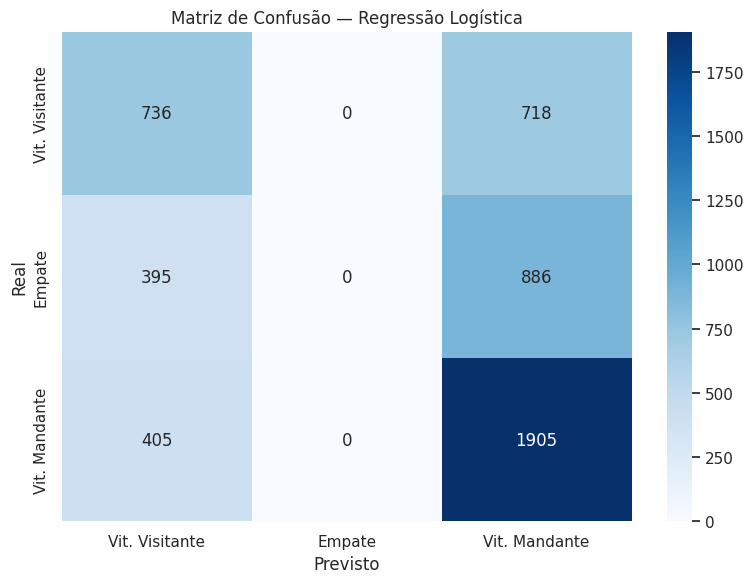

In [196]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

melhor_modelo = resultados['Regressão Logística']['modelo']
y_pred = melhor_modelo.predict(X_test)

# Relatório completo
print("=== Classification Report ===\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Vitória Visitante', 'Empate', 'Vitória Mandante']
))

# Matriz de confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Vit. Visitante', 'Empate', 'Vit. Mandante'],
    yticklabels=['Vit. Visitante', 'Empate', 'Vit. Mandante']
)
plt.title('Matriz de Confusão — Regressão Logística')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.savefig('assets/matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

Corrigindo o desbalanceamento

In [197]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# class_weight='balanced' faz o modelo penalizar mais os erros nas classes raras
modelos_balanceados = {
    'Regressão Logística (bal)': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest (bal)': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'
    ),
}

for nome, modelo in modelos_balanceados.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*50}")
    print(f"{nome} — Acurácia: {acc:.3f}")
    print(classification_report(
        y_test, y_pred,
        target_names=['Vitória Visitante', 'Empate', 'Vitória Mandante'],
        zero_division=0
    ))


Regressão Logística (bal) — Acurácia: 0.493
                   precision    recall  f1-score   support

Vitória Visitante       0.46      0.59      0.52      1454
           Empate       0.30      0.27      0.29      1281
 Vitória Mandante       0.63      0.56      0.59      2310

         accuracy                           0.49      5045
        macro avg       0.46      0.47      0.46      5045
     weighted avg       0.50      0.49      0.49      5045


Random Forest (bal) — Acurácia: 0.482
                   precision    recall  f1-score   support

Vitória Visitante       0.45      0.43      0.44      1454
           Empate       0.25      0.12      0.16      1281
 Vitória Mandante       0.54      0.72      0.62      2310

         accuracy                           0.48      5045
        macro avg       0.41      0.42      0.41      5045
     weighted avg       0.44      0.48      0.45      5045



Enriquecendo as features

Força ofensiva recente do visitante sofrendo gols defesa do mandante

In [198]:

features_base['media_gols_sofridos_visitante'] = (
    features_base
    .groupby('away_team_api_id')['away_team_goal']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)



Força defensiva recente do mandante gols sofridos em casa

In [199]:
features_base['media_gols_sofridos_mandante'] = (
    features_base
    .groupby('home_team_api_id')['home_team_goal']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)



 Diferença de forma recente quem está em melhor momento

In [200]:
features_base['diff_forma_recente'] = (
    features_base['media_gols_mandante_recente'] -
    features_base['media_gols_visitante_recente']
)



Se o jogo é "equilibrado" em rating

In [201]:

features_base['jogo_equilibrado'] = (
    abs(features_base['diff_rating']) < 0.5
).astype(int)



Conferindo

In [202]:

features_base[[
    'media_gols_sofridos_visitante',
    'media_gols_sofridos_mandante',
    'diff_forma_recente',
    'jogo_equilibrado'
]].head()

,media_gols_sofridos_visitante,media_gols_sofridos_mandante,diff_forma_recente,jogo_equilibrado
0,NaN,NaN,-1.292249,1
1,NaN,NaN,-2.438992,0
2,NaN,NaN,0.623857,1
3,NaN,NaN,-0.550641,1
4,NaN,NaN,-0.039355,1


Atualizando o X com as novas colunas

In [203]:
colunas_features = [
    'rating_mandante',
    'rating_visitante',
    'diff_rating',
    'media_gols_mandante_recente',
    'media_gols_visitante_recente',
    'taxa_vitoria_casa_mandante',
    'media_gols_sofridos_visitante',
    'media_gols_sofridos_mandante',
    'diff_forma_recente',
    'jogo_equilibrado',
]

X = features_base[colunas_features]
y = features_base['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



# Treinar a Logística balanceada com as novas features

In [205]:

# Ver quantos NaN tem em cada coluna
print(X.isnull().sum())

rating_mandante                    0
rating_visitante                   0
diff_rating                        0
media_gols_mandante_recente        0
media_gols_visitante_recente       0
taxa_vitoria_casa_mandante         0
media_gols_sofridos_visitante    299
media_gols_sofridos_mandante     299
diff_forma_recente                 0
jogo_equilibrado                   0
dtype: int64


In [206]:
# Preencher NaN com a mediana de cada coluna
X = X.fillna(X.median())

# Refazer o split com X limpo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Treinar
modelo = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(
    y_test, y_pred,
    target_names=['Vitória Visitante', 'Empate', 'Vitória Mandante'],
    zero_division=0
))

Acurácia: 0.489
                   precision    recall  f1-score   support

Vitória Visitante       0.47      0.55      0.51      1454
           Empate       0.30      0.31      0.30      1281
 Vitória Mandante       0.63      0.55      0.59      2310

         accuracy                           0.49      5045
        macro avg       0.47      0.47      0.47      5045
     weighted avg       0.50      0.49      0.49      5045



Otimizando os hiperparâmetros

In [207]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

parametros = {
    'C': [0.01, 0.1, 1, 10, 100],         # controla regularização (quanto o modelo "acredita" nos dados)
    'solver': ['lbfgs', 'saga'],            # algoritmo de otimização interno
    'max_iter': [1000],
    'class_weight': ['balanced'],
}

grid = GridSearchCV(
    LogisticRegression(random_state=42),
    parametros,
    cv=5,                    # 5-fold cross validation
    scoring='f1_macro',      # otimiza o F1 macro (melhor métrica pro nosso caso)
    n_jobs=-1,               # usa todos os núcleos do processador
    verbose=1
)

grid.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Melhor F1 macro (CV): {grid.best_score_:.3f}")



Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhores parâmetros: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'saga'}
Melhor F1 macro (CV): 0.461


Avaliar no teste

In [208]:

y_pred_grid = grid.best_estimator_.predict(X_test)

print(f"\nAcurácia no teste: {accuracy_score(y_test, y_pred_grid):.3f}")
print(classification_report(
    y_test, y_pred_grid,
    target_names=['Vitória Visitante', 'Empate', 'Vitória Mandante'],
    zero_division=0
))


Acurácia no teste: 0.489
                   precision    recall  f1-score   support

Vitória Visitante       0.47      0.55      0.51      1454
           Empate       0.30      0.31      0.30      1281
 Vitória Mandante       0.63      0.55      0.59      2310

         accuracy                           0.49      5045
        macro avg       0.47      0.47      0.47      5045
     weighted avg       0.50      0.49      0.49      5045



Tentando o XGBoost

In [209]:
# instalar se necessário
# !pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    # XGBoost não tem class_weight, usamos scale_pos_weight só para binário
    # para multiclasse, passamos pesos pelo sample_weight no fit
)

# Calcular pesos das amostras manualmente
from sklearn.utils.class_weight import compute_sample_weight

pesos = compute_sample_weight(class_weight='balanced', y=y_train)

modelo_xgb.fit(X_train, y_train, sample_weight=pesos)
y_pred_xgb = modelo_xgb.predict(X_test)

print(f"Acurácia XGBoost: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(classification_report(
    y_test, y_pred_xgb,
    target_names=['Vitória Visitante', 'Empate', 'Vitória Mandante'],
    zero_division=0
))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:06:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Acurácia XGBoost: 0.484
                   precision    recall  f1-score   support

Vitória Visitante       0.47      0.57      0.51      1454
           Empate       0.30      0.31      0.30      1281
 Vitória Mandante       0.63      0.52      0.57      2310

         accuracy                           0.48      5045
        macro avg       0.46      0.47      0.46      5045
     weighted avg       0.50      0.48      0.49      5045




Regressão Logística tem coeficientes por classe

In [210]:
modelo_final = grid.best_estimator_

classes = ['Vitória Visitante', 'Empate', 'Vitória Mandante']
coeficientes = pd.DataFrame(
    modelo_final.coef_,
    columns=X.columns,
    index=classes
)

Plotar importância por classe

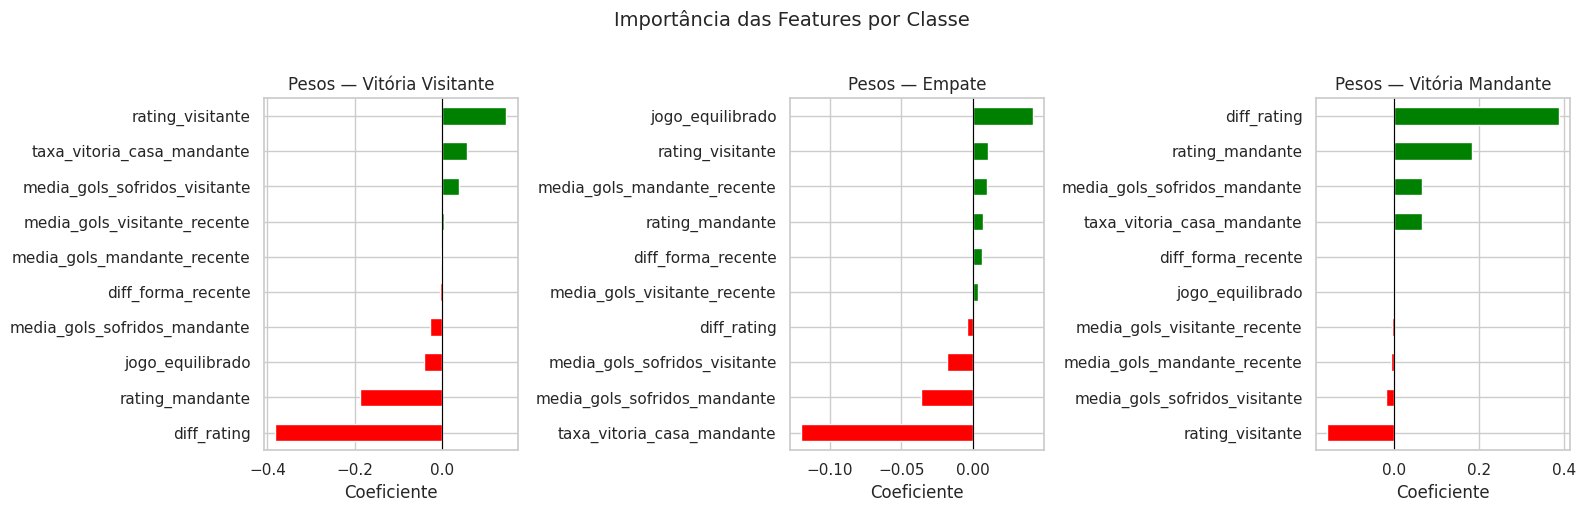


Coeficientes por classe:
                               Vitória Visitante  Empate  Vitória Mandante
rating_mandante                           -0.189   0.007             0.182
rating_visitante                           0.147   0.011            -0.158
diff_rating                               -0.382  -0.004             0.386
media_gols_mandante_recente               -0.003   0.010            -0.007
media_gols_visitante_recente               0.003   0.004            -0.007
taxa_vitoria_casa_mandante                 0.055  -0.120             0.065
media_gols_sofridos_visitante              0.037  -0.018            -0.019
media_gols_sofridos_mandante              -0.029  -0.036             0.065
diff_forma_recente                        -0.006   0.006            -0.000
jogo_equilibrado                          -0.041   0.042            -0.001


In [213]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, classe in enumerate(classes):
    coef = coeficientes.loc[classe].sort_values()
    cores = ['red' if v < 0 else 'green' for v in coef]
    coef.plot(kind='barh', ax=axes[i], color=cores)
    axes[i].set_title(f'Pesos — {classe}')
    axes[i].axvline(x=0, color='black', linewidth=0.8)
    axes[i].set_xlabel('Coeficiente')

plt.suptitle('Importância das Features por Classe', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('assets/importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCoeficientes por classe:")
print(coeficientes.T.round(3))

Conclusão e salvamento do modelo

In [215]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(grid.best_estimator_, 'models/modelo_final.pkl')
joblib.dump(X.columns.tolist(), 'models/features_utilizadas.pkl')

print("Modelo salvo com sucesso!")
print(f"Features salvas: {X.columns.tolist()}")

Modelo salvo com sucesso!
Features salvas: ['rating_mandante', 'rating_visitante', 'diff_rating', 'media_gols_mandante_recente', 'media_gols_visitante_recente', 'taxa_vitoria_casa_mandante', 'media_gols_sofridos_visitante', 'media_gols_sofridos_mandante', 'diff_forma_recente', 'jogo_equilibrado']


In [216]:
import ipywidgets as widgets
from IPython.display import display, clear_output


modelo = joblib.load('models/modelo_final.pkl')

# ─── Sliders ───────────────────────────────────────────
titulo = widgets.HTML("<h2>⚽ Simulador de Resultado de Partida</h2>")

rating_m = widgets.FloatSlider(value=74, min=50, max=95, step=0.5,
    description='Rating Mandante:', style={'description_width': '180px'}, layout=widgets.Layout(width='500px'))

rating_v = widgets.FloatSlider(value=74, min=50, max=95, step=0.5,
    description='Rating Visitante:', style={'description_width': '180px'}, layout=widgets.Layout(width='500px'))

gols_m = widgets.FloatSlider(value=1.5, min=0, max=5, step=0.1,
    description='Média Gols Mandante:', style={'description_width': '180px'}, layout=widgets.Layout(width='500px'))

gols_v = widgets.FloatSlider(value=1.5, min=0, max=5, step=0.1,
    description='Média Gols Visitante:', style={'description_width': '180px'}, layout=widgets.Layout(width='500px'))

taxa_casa = widgets.FloatSlider(value=0.45, min=0, max=1, step=0.01,
    description='Taxa Vitória Casa:', style={'description_width': '180px'}, layout=widgets.Layout(width='500px'))

gols_sof_v = widgets.FloatSlider(value=1.3, min=0, max=5, step=0.1,
    description='Gols Sofridos Visit.:', style={'description_width': '180px'}, layout=widgets.Layout(width='500px'))

gols_sof_m = widgets.FloatSlider(value=1.3, min=0, max=5, step=0.1,
    description='Gols Sofridos Mand.:', style={'description_width': '180px'}, layout=widgets.Layout(width='500px'))

botao = widgets.Button(description='🔮 Prever Resultado',
    button_style='primary', layout=widgets.Layout(width='250px', height='40px'))

output = widgets.Output()

# ─── Função de previsão ────────────────────────────────
def prever(b):
    with output:
        clear_output()

        diff = rating_m.value - rating_v.value
        diff_forma = gols_m.value - gols_v.value
        equilibrado = int(abs(diff) < 0.5)

        entrada = pd.DataFrame([{
            'rating_mandante':               rating_m.value,
            'rating_visitante':              rating_v.value,
            'diff_rating':                   diff,
            'media_gols_mandante_recente':   gols_m.value,
            'media_gols_visitante_recente':  gols_v.value,
            'taxa_vitoria_casa_mandante':    taxa_casa.value,
            'media_gols_sofridos_visitante': gols_sof_v.value,
            'media_gols_sofridos_mandante':  gols_sof_m.value,
            'diff_forma_recente':            diff_forma,
            'jogo_equilibrado':              equilibrado,
        }])

        prob = modelo.predict_proba(entrada)[0]
        previsao = modelo.predict(entrada)[0]
        mapa = {2: '🏠 Vitória Mandante', 1: '🤝 Empate', 0: '✈️ Vitória Visitante'}

        print("=" * 40)
        print(f"  RESULTADO PREVISTO: {mapa[previsao]}")
        print("=" * 40)
        print(f"\n  🏠 Vitória Mandante:  {prob[2]:.1%}")
        print(f"  🤝 Empate:            {prob[1]:.1%}")
        print(f"  ✈️  Vitória Visitante: {prob[0]:.1%}")
        print("=" * 40)

botao.on_click(prever)

# ─── Exibir tudo ───────────────────────────────────────
display(titulo, rating_m, rating_v, gols_m, gols_v,
        taxa_casa, gols_sof_v, gols_sof_m, botao, output)

HTML(value='<h2>⚽ Simulador de Resultado de Partida</h2>')

FloatSlider(value=74.0, description='Rating Mandante:', layout=Layout(width='500px'), max=95.0, min=50.0, step…

FloatSlider(value=74.0, description='Rating Visitante:', layout=Layout(width='500px'), max=95.0, min=50.0, ste…

FloatSlider(value=1.5, description='Média Gols Mandante:', layout=Layout(width='500px'), max=5.0, style=Slider…

FloatSlider(value=1.5, description='Média Gols Visitante:', layout=Layout(width='500px'), max=5.0, style=Slide…

FloatSlider(value=0.45, description='Taxa Vitória Casa:', layout=Layout(width='500px'), max=1.0, step=0.01, st…

FloatSlider(value=1.3, description='Gols Sofridos Visit.:', layout=Layout(width='500px'), max=5.0, style=Slide…

FloatSlider(value=1.3, description='Gols Sofridos Mand.:', layout=Layout(width='500px'), max=5.0, style=Slider…

Button(button_style='primary', description='🔮 Prever Resultado', layout=Layout(height='40px', width='250px'), …

Output()

In [217]:
# Rodar no Colab para zipar tudo
import shutil
shutil.make_archive('projeto_futebol', 'zip', '.', '.')

'/content/projeto_futebol.zip'

In [218]:
import os

os.makedirs('assets', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("Pastas criadas!")

Pastas criadas!


In [219]:
# Ver o que tem na pasta atual
for pasta in ['.', 'assets', 'models']:
    print(f"\n📁 {pasta}/")
    for arquivo in os.listdir(pasta):
        print(f"   {arquivo}")


📁 ./
   .config
   soccer
   projeto_futebol.zip
   models
   database.sqlite
   assets
   archive.zip
   sample_data

📁 assets/
   distribuicao_peso.png
   distribuicao_idade.png
   matriz_confusao.png
   distribuicao_altura.png
   distribuicao_gols_partida.png
   media_gols_liga.png
   mandante_x_visitante_liga.png
   mandante_x_visitante.png
   importancia_features.png
   top10_times_mandantes.png

📁 models/
   features_utilizadas.pkl
   modelo_final.pkl


In [220]:
import zipfile

arquivos = {
    'assets/': None,           # pasta inteira
    'models/': None,           # pasta inteira
    'eda_2.ipynb': None,       # notebook
}

with zipfile.ZipFile('github_soccer_analysis.zip', 'w') as zf:

    # Assets
    for arquivo in os.listdir('assets'):
        zf.write(f'assets/{arquivo}')

    # Models
    for arquivo in os.listdir('models'):
        zf.write(f'models/{arquivo}')

    # Notebook
    if os.path.exists('eda_2.ipynb'):
        zf.write('eda_2.ipynb')

print("✅ ZIP criado: github_soccer_analysis.zip")
print("\nConteúdo:")
with zipfile.ZipFile('github_soccer_analysis.zip', 'r') as zf:
    for nome in zf.namelist():
        print(f"  {nome}")

✅ ZIP criado: github_soccer_analysis.zip

Conteúdo:
  assets/distribuicao_peso.png
  assets/.ipynb_checkpoints/
  assets/simulador.png
  assets/distribuicao_idade.png
  assets/matriz_confusao.png
  assets/distribuicao_altura.png
  assets/distribuicao_gols_partida.png
  assets/media_gols_liga.png
  assets/mandante_x_visitante_liga.png
  assets/mandante_x_visitante.png
  assets/importancia_features.png
  assets/top10_times_mandantes.png
  models/features_utilizadas.pkl
  models/modelo_final.pkl


In [221]:
from google.colab import files
files.download('github_soccer_analysis.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>